<a href="https://colab.research.google.com/github/1FATIMAH1/IT362/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IT 362 Data Science Project – Phase 2

## Primary Data Processing, Cleaning, and Descriptive Analysis

In this section, we will clean and prepare the primary SATEL real estate dataset collected in Phase 1. Then, we will use the cleaned data to calculate descriptive statistics and create visualizations to understand the data better.

### 1. Import Libraries

We first import the Python libraries needed to clean, analyze, and visualize the data.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2. Load the Primary Dataset

The primary dataset collected and prepared during Phase 1 is loaded from the CSV file. The dataset contains the annual residential rental properties selected from SATEL.

In [ ]:
df = pd.read_csv('riyadh_annual_rentals_collected-3.csv')

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Number of rows: 218
Number of columns: 14


,property_id,neighborhood,neighborhood_ar,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,furnishing,status,title_text,created_at,source_url,collection_date
0,C0055,An Narjis,النرجس,Compounds,110000,139.0,3,4,Unfurnished,Available,Satel at Opal on Thoumamah Road - 3 Bedrooms A...,2026-04-06T14:15:09.408Z,https://apiv2.satel.sa/property/filter,2026-09-11
1,C0087,Al Olaya,العليا,Apartments,160000,112.0,2,3,Fully furnished,Available,Olaris More Than Just a Place to Live,2026-07-27T11:56:07.417Z,https://apiv2.satel.sa/property/filter,2026-09-11
2,A0177,An Narjis,النرجس,Compounds,140000,132.0,3,3,Fully furnished,Available,Satel at Opal — New Furnished & Unfurnished Ap...,2025-09-18T08:36:48.027Z,https://apiv2.satel.sa/property/filter,2026-09-11
3,C0052,Al Malaz,حي الملز,Compounds,73000,95.0,2,2,Fully furnished,Rented out,La Brise Community – Furnished 2 Beds with Bal...,2026-03-17T20:01:56.262Z,https://apiv2.satel.sa/property/filter,2026-09-11
4,C0084,An Nakheel,حي النخيل,Villas,370000,460.0,6,6,Partially furnished,Rented out,"Creative Community Where Comfort, Privacy, and...",2026-07-25T12:14:26.397Z,https://apiv2.satel.sa/property/filter,2026-09-11


In [ ]:
print(df.columns.tolist())

['property_id', 'neighborhood', 'neighborhood_ar', 'property_type', 'annual_rent_sar', 'area_sqm', 'bedrooms', 'bathrooms', 'furnishing', 'status', 'title_text', 'created_at', 'source_url', 'collection_date']


### 3. Initial Data Inspection

We first check the dataset structure, column names, and data types to better understand the data before cleaning.

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
df.info()

Dataset shape: (218, 14)

Column names:
['property_id', 'neighborhood', 'neighborhood_ar', 'property_type', 'annual_rent_sar', 'area_sqm', 'bedrooms', 'bathrooms', 'furnishing', 'status', 'title_text', 'created_at', 'source_url', 'collection_date']

Data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_id      218 non-null    object 
 1   neighborhood     218 non-null    object 
 2   neighborhood_ar  201 non-null    object 
 3   property_type    218 non-null    object 
 4   annual_rent_sar  218 non-null    int64  
 5   area_sqm         218 non-null    float64
 6   bedrooms         218 non-null    int64  
 7   bathrooms        218 non-null    int64  
 8   furnishing       218 non-null    object 
 9   status           218 non-null    object 
 10  title_text       218 non-null    object 
 11  created_at       218 non-null 

### 4. Check for Missing Values

We check the dataset for missing values before cleaning. This helps us identify which columns have missing data and decide how they should be handled.

In [ ]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
neighborhood_ar    17
dtype: int64


### 5. Check for Duplicate Records

We check for duplicate property IDs to make sure the same property is not counted more than once in the analysis.


In [ ]:
duplicate_ids = df['property_id'].duplicated().sum()

print("Duplicated property IDs:", duplicate_ids)

Duplicated property IDs: 0


### 6. Select Relevant Features

The dataset contains 14 columns. For the analysis, we select the features related to the property location, type, rental price, size, characteristics, and listing information. The source URL and collection date are not needed for the analysis, so they are excluded.

In [ ]:
selected_columns = [
    'property_id',
    'neighborhood',
    'neighborhood_ar',
    'property_type',
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'furnishing',
    'status',
    'title_text',
    'created_at'
]

df = df[selected_columns].copy()

print("Dataset shape after selecting relevant features:", df.shape)
df.head()

Dataset shape after selecting relevant features: (218, 12)


,property_id,neighborhood,neighborhood_ar,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,furnishing,status,title_text,created_at
0,C0055,An Narjis,النرجس,Compounds,110000,139.0,3,4,Unfurnished,Available,Satel at Opal on Thoumamah Road - 3 Bedrooms A...,2026-04-06T14:15:09.408Z
1,C0087,Al Olaya,العليا,Apartments,160000,112.0,2,3,Fully furnished,Available,Olaris More Than Just a Place to Live,2026-07-27T11:56:07.417Z
2,A0177,An Narjis,النرجس,Compounds,140000,132.0,3,3,Fully furnished,Available,Satel at Opal — New Furnished & Unfurnished Ap...,2025-09-18T08:36:48.027Z
3,C0052,Al Malaz,حي الملز,Compounds,73000,95.0,2,2,Fully furnished,Rented out,La Brise Community – Furnished 2 Beds with Bal...,2026-03-17T20:01:56.262Z
4,C0084,An Nakheel,حي النخيل,Villas,370000,460.0,6,6,Partially furnished,Rented out,"Creative Community Where Comfort, Privacy, and...",2026-07-25T12:14:26.397Z


### 7. Check Missing Values in Selected Features

After selecting the relevant features, we check for missing values again to see if any of the selected features need to be treated.

In [ ]:
missing_selected = df.isnull().sum()

print("Missing values in selected features:")
print(missing_selected)

Missing values in selected features:
property_id         0
neighborhood        0
neighborhood_ar    17
property_type       0
annual_rent_sar     0
area_sqm            0
bedrooms            0
bathrooms           0
furnishing          0
status              0
title_text          0
created_at          0
dtype: int64


**Finding:** The neighborhood_ar feature has 17 missing values. These records were kept because the neighborhood feature has no missing values and can still be used for the analysis. Therefore, no rows were removed.

### 8. Check and Correct Data Types

We check the data types of the selected features to make sure they are stored correctly. Numerical features should be numeric, while the listing creation date should be stored as a datetime.

In [ ]:
print(df.dtypes)

property_id         object
neighborhood        object
neighborhood_ar     object
property_type       object
annual_rent_sar      int64
area_sqm           float64
bedrooms             int64
bathrooms            int64
furnishing          object
status              object
title_text          object
created_at          object
dtype: object


### 9. Convert Date Variable

The `created_at` feature is stored as an object, so we convert it to a datetime data type to represent the listing dates correctly.

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print(df.dtypes)

property_id                     object
neighborhood                    object
neighborhood_ar                 object
property_type                   object
annual_rent_sar                  int64
area_sqm                       float64
bedrooms                         int64
bathrooms                        int64
furnishing                      object
status                          object
title_text                      object
created_at         datetime64[ns, UTC]
dtype: object


In [ ]:
print("Missing created_at values:", df['created_at'].isnull().sum())

Missing created_at values: 0


**Finding:** The created_at feature was successfully converted from an object to a datetime data type. The other selected features already had appropriate data types.

### 10. Check Numerical Values

We check the main numerical features for invalid or suspicious values, such as negative rental prices, zero or negative property areas, or unusual bedroom and bathroom values.

In [ ]:
numeric_columns = [
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms'
]

df[numeric_columns].describe()

,annual_rent_sar,area_sqm,bedrooms,bathrooms
count,218.000000,218.000000,218.000000,218.000000
mean,121623.848624,151.094037,2.674312,3.073394
std,54589.760321,83.149380,0.905376,1.215919
min,50000.000000,0.000000,1.000000,1.000000
25%,85000.000000,110.000000,2.000000,2.000000
50%,110000.000000,129.000000,3.000000,3.000000
75%,140000.000000,154.750000,3.000000,3.000000
max,380000.000000,614.000000,7.000000,9.000000


**Finding:** The numerical features were checked for unusual values. Rental prices, bedrooms, and bathrooms have positive values. However, the minimum property area is 0 square meters, which is not a valid area and needs further investigation.

### 11. Investigate Invalid Area Values

The numerical summary shows that the minimum property area is 0 square meters. Since a property cannot have an area of zero, we check the affected record before deciding how to treat it.

In [ ]:
zero_area = df[df['area_sqm'] <= 0]

print("Number of listings with zero or negative area:", len(zero_area))

zero_area[[
    'property_id',
    'neighborhood',
    'property_type',
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms',
    'title_text'
]]

Number of listings with zero or negative area: 1


,property_id,neighborhood,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,title_text
36,C0099,Alyasmin,Floor,75000,0.0,3,4,3 Bedroom Floor for Rent in Al Yasmin | SATEL


**Finding:** One property has an area of 0 square meters. Since the other information for this property is still useful, the record will be kept and only the invalid area value will be treated as missing.

### 12. Treat Invalid Area Value

One listing has a property area of 0 square meters. Since the correct area is unknown, the value is changed to missing instead of estimating it. The listing is kept because its other information is still useful for the analysis.

In [ ]:
import numpy as np

df.loc[df['area_sqm'] <= 0, 'area_sqm'] = np.nan

print("Missing area values after treatment:", df['area_sqm'].isnull().sum())
print("Number of records:", len(df))

Missing area values after treatment: 1
Number of records: 218


**Finding:** The invalid area value was changed to missing, while the property record was kept. The dataset still contains 218 records, with one missing value in area_sqm.

### 13. Check Categorical Values

We check the categorical features for inconsistent names, spelling differences, or unexpected categories that could affect the analysis.

In [ ]:
categorical_columns = [
    'neighborhood',
    'property_type',
    'furnishing',
    'status'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- neighborhood ---
neighborhood
Al Olaya                    40
An Narjis                   19
Al Malqa                    15
Al Wurud                    14
Al Aqiq                     12
Al Mathar Ash Shamali       12
An Nakheel                  12
Al Malaz                    10
Ar Rahmaniyyah               8
As Sulimaniyah               8
Al Mohammadiyyah             8
Alyasmin                     7
As Sahafah                   6
Hittin                       5
At Taawun                    5
Ar Rafiah                    4
Qurtubah                     4
King Salman Neighborhood     2
Al Ghadir                    2
Sedra                        2
Al Qirawan                   2
Al Murabba                   2
Al Muruj                     2
Al Aarid                     2
Almasiaf                     1
Irqah                        1
King Fahd                    1
Jarir                        1
Ar Rawdah                    1
Al Wadi                      1
An Nada                      1
An N

### 14. Standardize Neighborhood Names

The neighborhood names are checked for different spellings and formats. Some neighborhoods appear more than once because they are written differently or in Arabic. These values are standardized so that each neighborhood is treated as one category during the analysis.

In [ ]:
df['neighborhood'] = df['neighborhood'].replace({
    'Al-Aqiq': 'Al Aqiq',
    'Aarid': 'Al Aarid',
    'حي الملز': 'Al Malaz',
    'حي الملقا': 'Al Malqa'
})

print(df['neighborhood'].value_counts())

neighborhood
Al Olaya                    40
An Narjis                   19
Al Malqa                    16
Al Wurud                    14
Al Aqiq                     13
Al Mathar Ash Shamali       12
An Nakheel                  12
Al Malaz                    11
As Sulimaniyah               8
Ar Rahmaniyyah               8
Al Mohammadiyyah             8
Alyasmin                     7
As Sahafah                   6
Hittin                       5
At Taawun                    5
Qurtubah                     4
Ar Rafiah                    4
Al Aarid                     3
King Salman Neighborhood     2
Al Murabba                   2
Al Muruj                     2
Sedra                        2
Al Ghadir                    2
Al Qirawan                   2
Irqah                        1
King Fahd                    1
Almasiaf                     1
Jarir                        1
An Nada                      1
Al Wadi                      1
Ar Rawdah                    1
An Nuzhah                 

**Finding:**  Inconsistent neighborhood names were standardized to avoid treating the same neighborhood as different categories. No records were removed during this process.

## 15. Descriptive Statistics

Descriptive statistics are calculated for the main numerical features to summarize their values after data cleaning.

In [ ]:
numeric_columns = [
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms'
]

df[numeric_columns].describe()

,annual_rent_sar,area_sqm,bedrooms,bathrooms
count,218.000000,217.000000,218.000000,218.000000
mean,121623.848624,151.790323,2.674312,3.073394
std,54589.760321,82.702171,0.905376,1.215919
min,50000.000000,23.000000,1.000000,1.000000
25%,85000.000000,110.000000,2.000000,2.000000
50%,110000.000000,129.000000,3.000000,3.000000
75%,140000.000000,156.000000,3.000000,3.000000
max,380000.000000,614.000000,7.000000,9.000000


### Interpretation of Descriptive Statistics

The cleaned dataset contains 218 residential rental listings. Annual rental prices range from 50,000 SAR to 380,000 SAR, with an average of approximately 121,624 SAR and a median of 110,000 SAR. Property area has 217 valid observations because one invalid zero-area value was treated as missing. The average property area is approximately 152 square meters. The listings have an average of approximately 2.67 bedrooms and 3.07 bathrooms.

## 16. Distribution Plots

Distribution plots are used to understand how the main numerical features are distributed and to identify patterns or unusual values in the data.

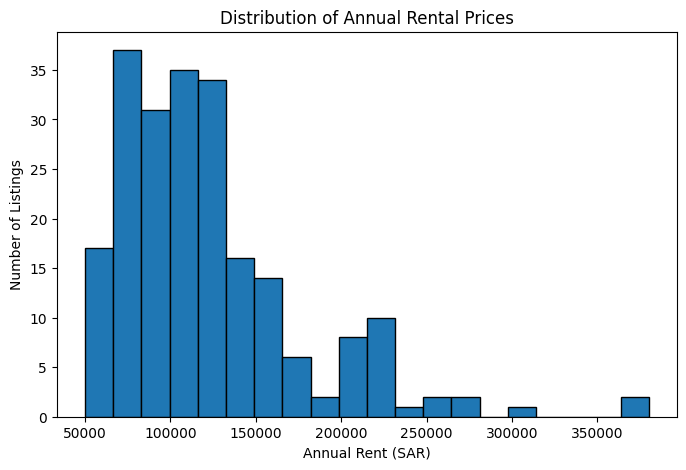

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(df['annual_rent_sar'], bins=20, edgecolor='black')

plt.title('Distribution of Annual Rental Prices')
plt.xlabel('Annual Rent (SAR)')
plt.ylabel('Number of Listings')

plt.show()

### Annual Rental Price Distribution

The annual rental prices are right-skewed. Most listings are between approximately 50,000 and 150,000 SAR per year, while fewer properties have much higher rental prices. This creates a long right tail in the distribution. The mean rent is also higher than the median, which supports this pattern.

### Property Area Distribution

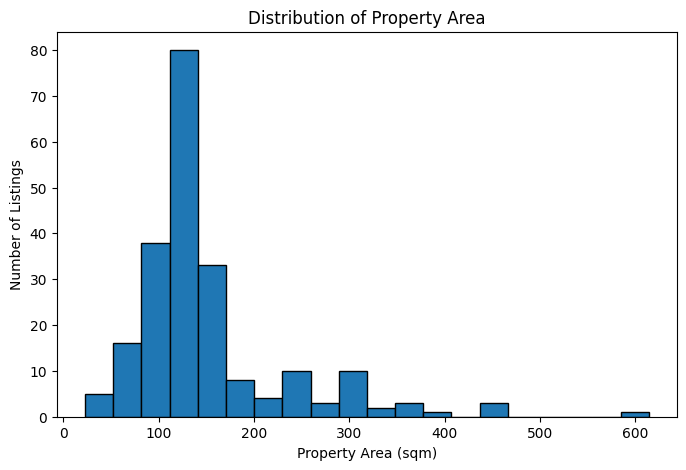

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['area_sqm'].dropna(), bins=20, edgecolor='black')

plt.title('Distribution of Property Area')
plt.xlabel('Property Area (sqm)')
plt.ylabel('Number of Listings')

plt.show()

### Interpretation of Property Area Distribution

The property area distribution is right-skewed. Most properties have smaller to medium-sized areas, while fewer properties have much larger areas. These larger properties create a long right tail in the distribution.

### Bedroom Distribution

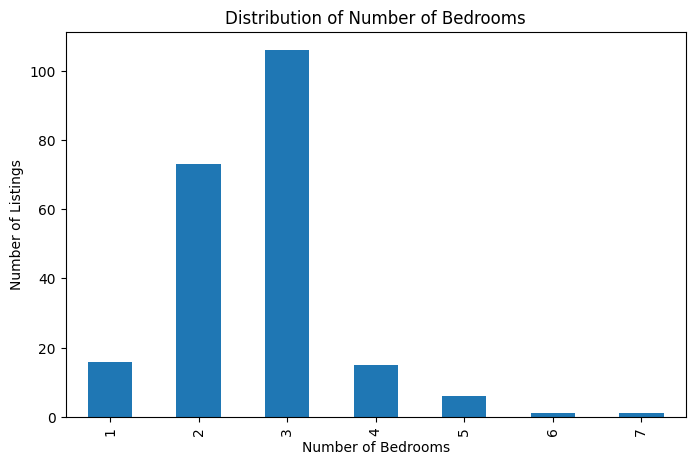

In [ ]:
plt.figure(figsize=(8,5))

df['bedrooms'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Number of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Number of Listings')

plt.show()

### Interpretation of Bedroom Distribution

Three-bedroom properties are the most common in the dataset, followed by two-bedroom properties. Properties with four or more bedrooms appear much less frequently, while six- and seven-bedroom properties are rare.

### Bathroom Distribution

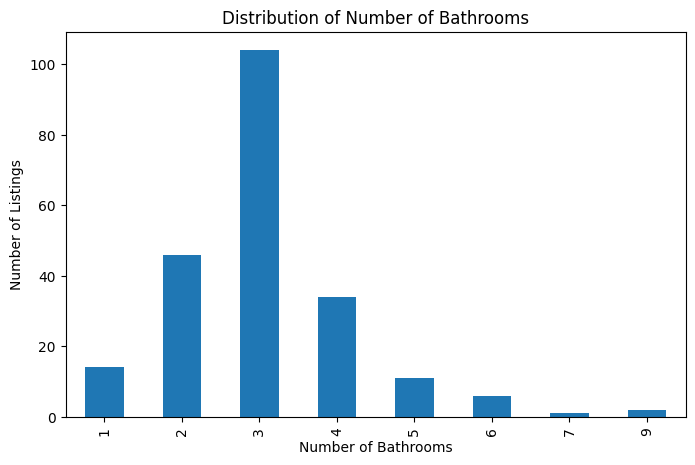

In [ ]:
plt.figure(figsize=(8,5))

df['bathrooms'].value_counts().sort_index().plot(kind='bar')

plt.title('Distribution of Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Number of Listings')

plt.show()

### Interpretation of Bathroom Distribution

Three-bathroom properties are the most common in the dataset, followed by properties with two and four bathrooms. Properties with five or more bathrooms appear much less frequently, while listings with seven or nine bathrooms are rare.

### Property Type Distribution

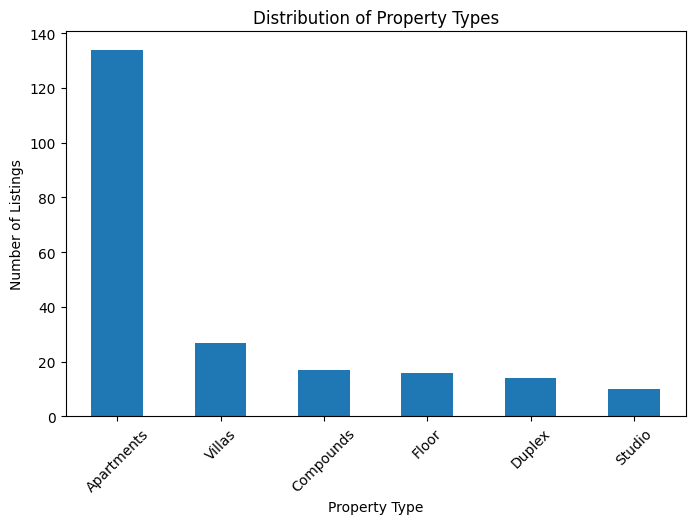

In [ ]:
plt.figure(figsize=(8,5))

df['property_type'].value_counts().plot(kind='bar')

plt.title('Distribution of Property Types')
plt.xlabel('Property Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)

plt.show()

### Interpretation Property Type Distribution

Apartments are the most common property type in the dataset, with 134 listings. Villas are the second most common with 27 listings, followed by compounds, floors, duplexes, and studios. This shows that the dataset contains more apartment listings compared with the other property types.

### Furnishing Distribution

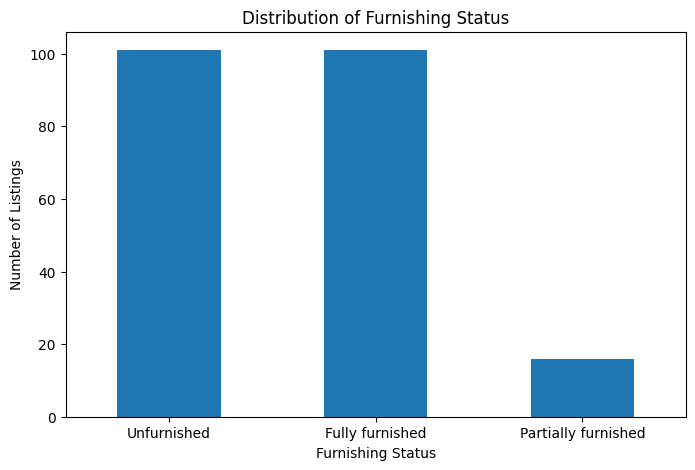

In [ ]:
plt.figure(figsize=(8,5))

df['furnishing'].value_counts().plot(kind='bar')

plt.title('Distribution of Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)

plt.show()

### Interpretation of Furnishing Distribution
Fully furnished and unfurnished properties are equally common in the dataset, with 101 listings each. Partially furnished properties are much less common, with only 16 listings.

### Listing Status Distribution

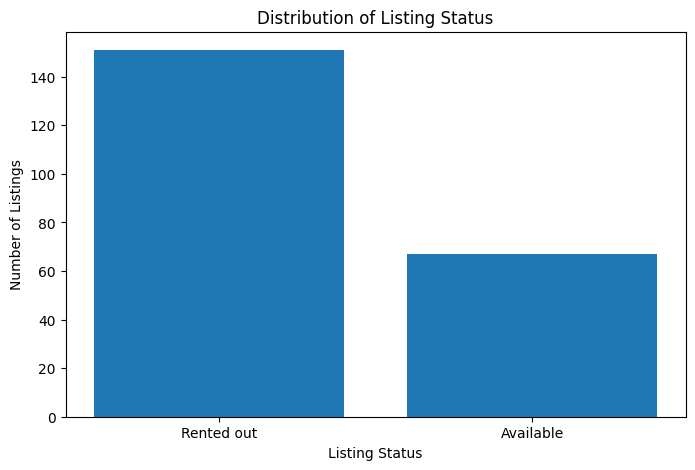

In [ ]:
status_counts = df['status'].value_counts()

plt.figure(figsize=(8,5))
plt.bar(status_counts.index, status_counts.values)

plt.title('Distribution of Listing Status')
plt.xlabel('Listing Status')
plt.ylabel('Number of Listings')

plt.show()

### Listing Status Distribution

Most properties in the dataset are already rented out. There are 151 rented-out listings compared with 67 available listings. This shows that rented-out properties make up the majority of the dataset.

In [ ]:
# Save the cleaned and processed dataset
df.to_csv('cleaned_satel_riyadh_rentals.csv', index=False)

print("Cleaned dataset saved successfully.")
print("Final dataset shape:", df.shape)

Cleaned dataset saved successfully.
Final dataset shape: (218, 12)


### Data Cleaning Summary

The dataset was checked for missing values, duplicate records, data types, categorical values, and invalid numerical values. No duplicate property IDs were found. The neighborhood_ar column had 17 missing values, but the records were kept because the English neighborhood names were available. The created_at column was converted to datetime format. One property had an area of 0 square meters, so this value was changed to missing while keeping the rest of the listing. Inconsistent neighborhood names were also standardized. After cleaning, the final dataset contains 218 listings and 12 features.

## 17. Relationships, Correlations and Group Comparisons

In this section, we explore how annual rental prices vary across property types and neighborhoods. We also examine relationships between rental prices and numerical property characteristics.


### Load the Cleaned Dataset

We load the cleaned SATEL dataset uploaded to Colab for our analysis. We use the cleaned data prepared in the previous stage to explore relationships and compare rental prices across groups.



In [ ]:
# Load the cleaned dataset
eda_df = pd.read_csv('cleaned_satel_riyadh_rentals.csv')

# Display the dataset dimensions
print("Number of rows:", eda_df.shape[0])
print("Number of columns:", eda_df.shape[1])

# Preview the first five rows
eda_df.head()

Number of rows: 218
Number of columns: 12


,property_id,neighborhood,neighborhood_ar,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,furnishing,status,title_text,created_at
0,C0055,An Narjis,النرجس,Compounds,110000,139.0,3,4,Unfurnished,Available,Satel at Opal on Thoumamah Road - 3 Bedrooms A...,2026-04-06 14:15:09.408000+00:00
1,C0087,Al Olaya,العليا,Apartments,160000,112.0,2,3,Fully furnished,Available,Olaris More Than Just a Place to Live,2026-07-27 11:56:07.417000+00:00
2,A0177,An Narjis,النرجس,Compounds,140000,132.0,3,3,Fully furnished,Available,Satel at Opal — New Furnished & Unfurnished Ap...,2025-09-18 08:36:48.027000+00:00
3,C0052,Al Malaz,حي الملز,Compounds,73000,95.0,2,2,Fully furnished,Rented out,La Brise Community – Furnished 2 Beds with Bal...,2026-03-17 20:01:56.262000+00:00
4,C0084,An Nakheel,حي النخيل,Villas,370000,460.0,6,6,Partially furnished,Rented out,"Creative Community Where Comfort, Privacy, and...",2026-07-25 12:14:26.397000+00:00


## 18. Annual Rent by Property Type

We compare annual rental prices across property types to address our research question.

For each property type, we calculate the mean, median, and number of listings. The mean shows the average annual rent. The median is less affected by extreme prices and helps us interpret the mean. The count shows how many listings each comparison is based on.

In [ ]:
# Group listings by property type and summarize annual rent
rent_by_type = eda_df.groupby('property_type')['annual_rent_sar'].agg(
    ['count', 'mean', 'median']
).round(2)

# Display the comparison table
rent_by_type

,count,mean,median
property_type,,,
Apartments,134,104626.87,105000.0
Compounds,17,114058.82,120000.0
Duplex,14,166785.64,144999.5
Floor,16,97687.50,90000.0
Studio,10,72700.00,67500.0
Villas,27,219629.63,220000.0


### Interpretation of Rental Statistics by Property Type

Villas have the highest mean annual rent at approximately 219,630 SAR, while studios have the lowest at 72,700 SAR. Apartments have a mean annual rent of approximately 104,627 SAR.

The mean rent for duplexes is higher than the median, suggesting that higher-priced listings may be pulling the mean upward.

Group sizes are unequal: apartments have 134 listings, while studios have 10. These results describe the collected SATEL listings and should not be generalized to the entire Riyadh rental market.

### Average Annual Rent by Property Type

We use a bar chart to compare mean annual rents across property types. This chart is suitable for comparing a numerical value across categories. The bars are sorted from lowest to highest mean rent to make the differences easier to see.

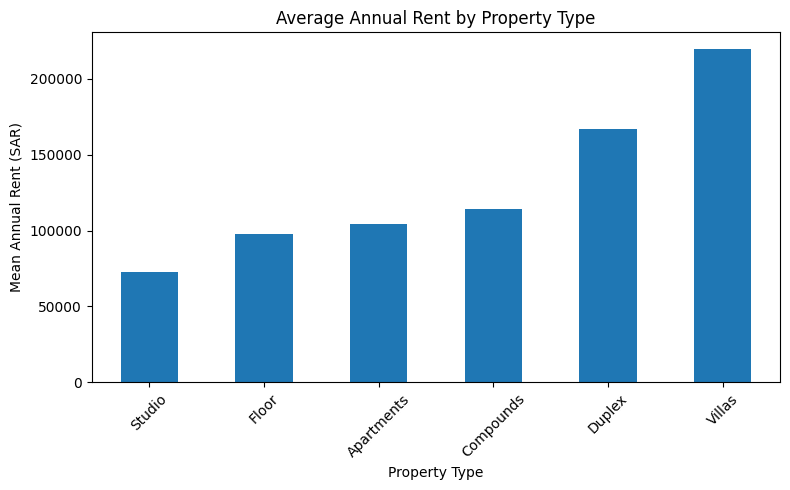

In [ ]:
import matplotlib.pyplot as plt

# Plot mean annual rent from lowest to highest
rent_by_type['mean'].sort_values().plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Annual Rent by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Mean Annual Rent (SAR)')
plt.xticks(rotation=45)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Interpretation of Average Annual Rent by Property Type
The chart shows that villas have the highest average annual rent, folloed by duplexes. Studios have the lowest average, while floors, apartments, and compounds fall between these groups.

Within the collected SATEL listings, the average rent for villas is approximately three times that of studios. These differences may also reflect other characteristics, such as property size and neighborhood, rather than property type alone.

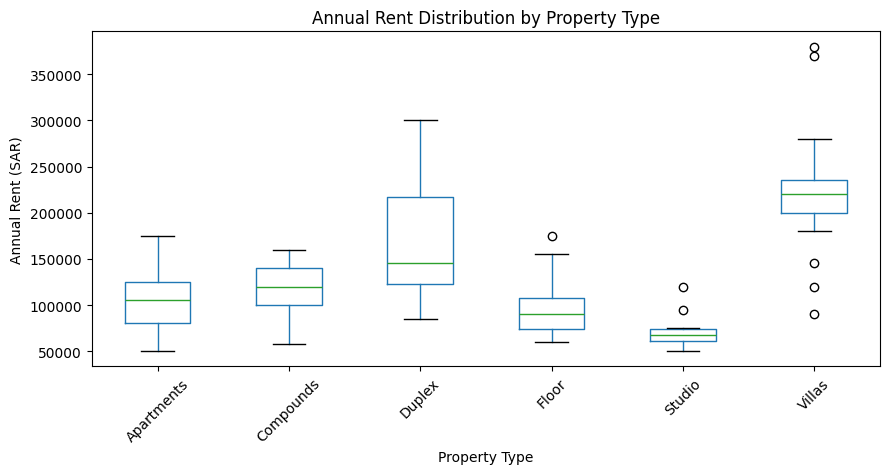

In [ ]:
# Compare annual rental distributions across property types
eda_df.boxplot(
    column='annual_rent_sar',
    by='property_type',
    figsize=(9, 5),
    grid=False
)

plt.title('Annual Rent Distribution by Property Type')
plt.suptitle('')
plt.xlabel('Property Type')
plt.ylabel('Annual Rent (SAR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretation of Rental Distributions by Property Typ
Villas have the highest median annual rent at 220,000 SAR, while studios have the lowest at 67,500 SAR. Duplexes have the widest interquartile range, indicating greater variation in the middle 50% of rental prices. These differences show that the mean alone does not fully describe rental prices within each property type.
Potential outliers appear in villas, studios, and floors. High values can raise the mean, while low values can lower it; the median is less affected. For example, studios have a mean rent of 72,700 SAR and a median of 67,500 SAR, with upper outliers contributing to this difference.

## 19. Annual Rent by Neighborhood

We group the listings by neighborhood and calculate the count, mean, and median annual rent to compare rental prices across locations.

The count helps identify neighborhoods with limited observations. Comparisons should be interpreted cautiously because neighborhoods have different sample sizes and may contain different mixes of property types.

In [ ]:
# Calculate rental statistics for each neighborhood
rent_by_neighborhood = eda_df.groupby('neighborhood')['annual_rent_sar'].agg(
    ['count', 'mean', 'median']
)

# Sort neighborhoods from highest to lowest mean rent
rent_by_neighborhood = rent_by_neighborhood.sort_values(
    by='mean',
    ascending=False
).round(2)

# Display all neighborhoods
display(rent_by_neighborhood)

,count,mean,median
neighborhood,,,
Sedra,2,235000.00,235000.0
An Nada,1,230000.00,230000.0
Ar Rabwah,1,230000.00,230000.0
Ar Rafiah,4,221250.00,220000.0
As Sahafah,6,205833.33,215000.0
Al Muruj,2,190000.00,190000.0
An Nakheel,12,175833.33,162500.0
An Nafal,1,175000.00,175000.0
Al Mohammadiyyah,8,140000.00,145000.0


### Interpretation of Rental Statistics by Neighborhood

Sedra has the highest observed mean annual rent at 235,000 SAR, but this is based on only two listings. An Nada and Ar Rabwah each have a mean of 230,000 SAR based on a single listing. These values should not be interpreted as representative averages for the entire neighborhoods.

Among neighborhoods with more listings, An Nakheel has a mean annual rent of approximately 175,833 SAR across 12 listings, compared with 123,158 SAR in An Narjis across 19 listings and 114,375 SAR in Al Olaya across 40 listings. In Qurtubah, the mean of 140,000 SAR exceeds the median of 100,000 SAR, indicating that higher-priced listings pull the mean upward.

These results show differences in advertised rents across the sampled neighborhoods. However, unequal sample sizes and differences in property types and sizes limit direct comparisons. The observed differences cannot be attributed to neighborhood alone.

### Average Annual Rent by Neighborhood

We use a horizontal bar chart to compare mean annual rents across neighborhoods. Horizontal bars make the neighborhood names easier to read, and sorting helps show differences clearly.

Each label includes the number of listings (n). Averages based on very few listings should be interpreted cautiously. Differences may also reflect the mix of property types in each neighborhood.

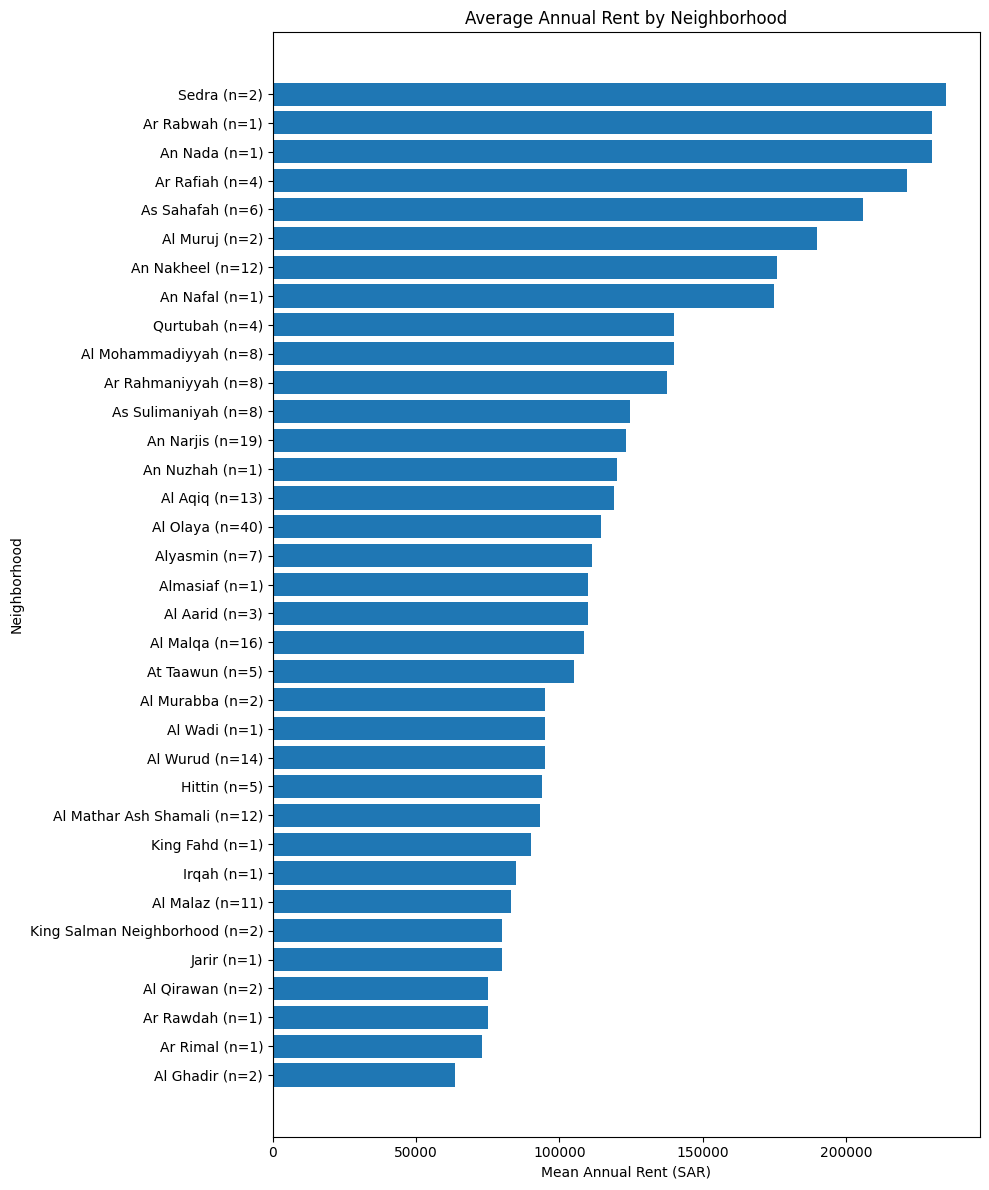

In [ ]:
# Sort neighborhoods by mean annual rent
neighborhood_plot = rent_by_neighborhood.sort_values('mean')

# Include the number of listings in each label
labels = [
    f"{name} (n={int(count)})"
    for name, count in zip(
        neighborhood_plot.index,
        neighborhood_plot['count']
    )
]

# Draw a horizontal bar chart
plt.figure(figsize=(10, 12))
plt.barh(labels, neighborhood_plot['mean'])

plt.title('Average Annual Rent by Neighborhood')
plt.xlabel('Mean Annual Rent (SAR)')
plt.ylabel('Neighborhood')
plt.xlim(left=0)
plt.tight_layout()
plt.show()

### Interpretation of Average Annual Rent by Neighborhood

Sedra has the highest mean annual rent in the sample at 235,000 SAR, while Al Ghadir has the lowest at approximately 63,500 SAR. Both neighborhoods are represented by only two listings, so these averages should not be treated as typical rents for the entire neighborhoods.

The labels show unequal numbers of listings across neighborhoods. For example, Al Olaya has 40 listings, whereas An Nada and Ar Rabwah each have one. The chart describes differences within the collected sample, which may also reflect differences in property types and sizes.

## 20. Relationship Between Property Area and Annual Rent

We use a scatter plot to explore whether larger properties tend to have higher annual rents. This plot is suitable because both area and rent are numerical variables, and each point represents one listing.

Listings with missing area or rent are excluded only from this analysis. They remain in the main dataset.

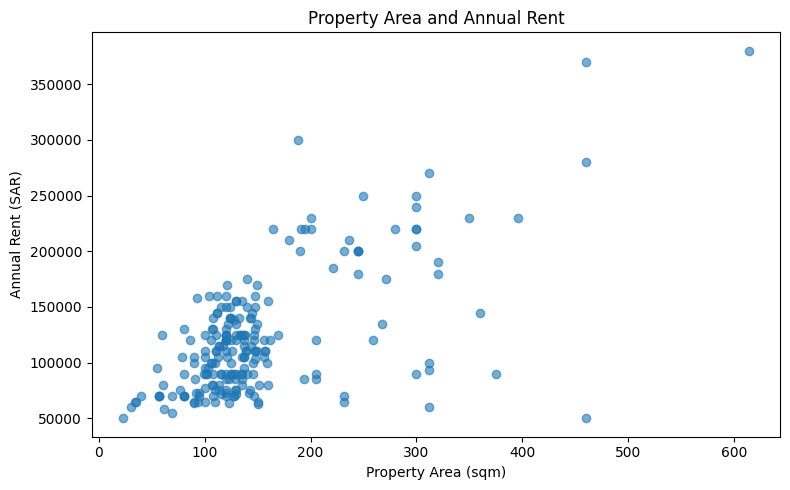

In [ ]:
# Keep listings with available area and rent
area_rent = eda_df.dropna(
    subset=['area_sqm', 'annual_rent_sar']
)

# Plot area against annual rent
plt.figure(figsize=(8, 5))
plt.scatter(
    area_rent['area_sqm'],
    area_rent['annual_rent_sar'],
    alpha=0.6
)

plt.title('Property Area and Annual Rent')
plt.xlabel('Property Area (sqm)')
plt.ylabel('Annual Rent (SAR)')
plt.tight_layout()
plt.show()

### Interpretation of Property Area and Annual Rent

The scatter plot suggests a positive relationship between property area and annual rent: larger properties generally tend to have higher rents. However, properties with similar areas can have different rental prices, indicating that area alone does not explain the variation in rent.

Some listings stand out from the overall pattern. For example, a property of approximately 460 sqm has an annual rent of 50,000 SAR. Such observations may reflect differences in property type, neighborhood, or listing accuracy and require further investigation. They are not automatically treated as errors.

### Correlation Between Property Area and Annual Rent

We calculate Pearson's correlation coefficient to summarize the direction and strength of the linear relationship between area and annual rent. Values closer to +1 indicate a stronger positive linear relationship, while values near 0 indicate a weak linear relationship.

Pearson's correlation can be affected by extreme observations, so we interpret it alongside the scatter plot. Correlation does not establish causation.

In [ ]:
# Calculate the linear correlation between area and annual rent
area_rent_correlation = area_rent['area_sqm'].corr(
    area_rent['annual_rent_sar']
)

print(
    "Pearson correlation between area and annual rent:",
    round(area_rent_correlation, 3)
)

Pearson correlation between area and annual rent: 0.637


### Interpretation of Area–Rent Correlation

The Pearson correlation between property area and annual rent is 0.637, indicating a moderately strong positive linear relationship in the collected SATEL listings. Larger properties generally tend to have higher annual rents, consistent with the upward pattern in the scatter plot.

However, this relationship is not perfect, and area alone does not explain rental prices. Neighborhood, property type, and other characteristics may also contribute to the observed differences. Extreme observations can affect Pearson's correlation, and the result does not establish causation.

## 21. Correlations Between Numerical Property Features

We calculate Pearson correlations between annual rent, property area, bedrooms, and bathrooms. These numerical variables help us explore how rental prices relate to property characteristics.

A heatmap displays the correlation coefficients using colors and numbers, making the direction and strength of the relationships easier to compare. These correlations describe linear associations and do not establish causation.

Missing values are excluded separately for each pair of variables, so the number of observations may differ between pairs.## 21. Correlations Between Numerical Property Features

We calculate Pearson correlations between annual rent, property area, bedrooms, and bathrooms. These numerical variables help us explore how rental prices relate to property characteristics.

A heatmap displays the correlation coefficients using colors and numbers, making the direction and strength of the relationships easier to compare. These correlations describe linear associations and do not establish causation.

Missing values are excluded separately for each pair of variables, so the number of observations may differ between pairs.

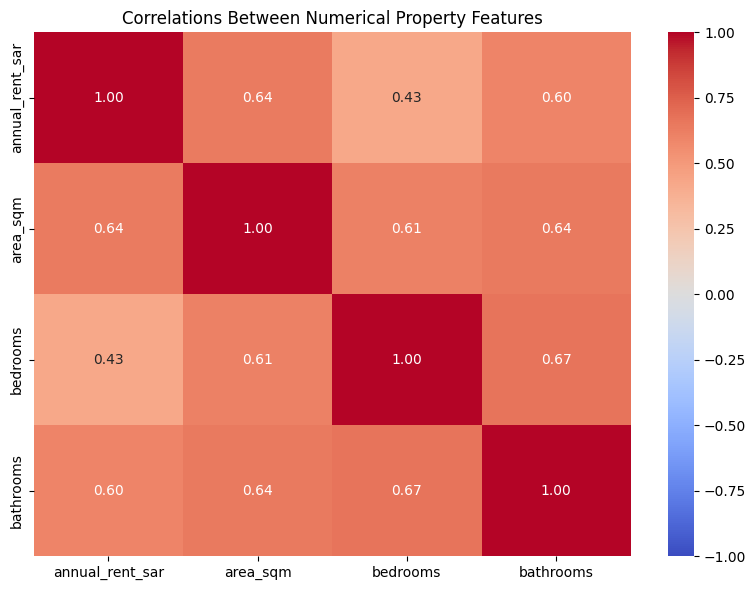

In [ ]:
import seaborn as sns

# Select numerical features relevant to the analysis
numerical_features = eda_df[
    ['annual_rent_sar', 'area_sqm', 'bedrooms', 'bathrooms']
]

# Calculate Pearson correlations
correlation_matrix = numerical_features.corr(method='pearson')

# Display the correlations as a heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Correlations Between Numerical Property Features')
plt.tight_layout()
plt.show()

### Interpretation of Correlations Between Numerical Property Features

Annual rent has positive correlations with property area (0.64), bathrooms (0.60), and bedrooms (0.43). Among these three characteristics, area has the strongest linear association with rent, while bedrooms have the weakest.

The property characteristics are also positively related. Bedrooms and bathrooms have a correlation of 0.67, while area correlates with bedrooms at 0.61 and bathrooms at 0.64. This suggests that larger properties tend to have more bedrooms and bathrooms.

These correlations describe relationships within the collected SATEL listings. They do not isolate the effect of each characteristic or establish causation. Property type, neighborhood, and extreme observations may also influence the observed relationships.

## 22. Apartment Rents by Neighborhood

We compare annual rents across neighborhoods using apartment listings only. Apartments are the most common property type in our dataset. Restricting the comparison to one property type reduces differences caused by the mix of property types across neighborhoods.

We report the count, mean, and median for each neighborhood. Apartment sizes, furnishing, and other characteristics may still differ, so this comparison does not isolate the effect of neighborhood.

In [ ]:
# Select apartment listings only
apartments = eda_df[
    eda_df['property_type'] == 'Apartments'
].copy()

# Summarize apartment rents in each neighborhood
apartment_rent_by_neighborhood = apartments.groupby(
    'neighborhood'
)['annual_rent_sar'].agg(['count', 'mean', 'median'])

# Sort from highest to lowest mean rent
apartment_rent_by_neighborhood = (
    apartment_rent_by_neighborhood
    .sort_values('mean', ascending=False)
    .round(2)
)

display(apartment_rent_by_neighborhood)

,count,mean,median
neighborhood,,,
An Nafal,1,175000.00,175000.0
As Sahafah,2,142500.00,142500.0
Al Mohammadiyyah,8,140000.00,145000.0
An Nakheel,7,137142.86,125000.0
As Sulimaniyah,4,124500.00,117500.0
Al Mathar Ash Shamali,7,111428.57,110000.0
Al Muruj,1,110000.00,110000.0
Almasiaf,1,110000.00,110000.0
Al Aqiq,11,108454.55,105000.0


### Interpretation of Apartment Rents by Neighborhood

Average apartment rents vary across the sampled neighborhoods. Al Mohammadiyyah has a mean annual rent of 140,000 SAR based on eight listings, compared with approximately 102,333 SAR in Al Olaya based on 30 listings. An Nafal has the highest mean at 175,000 SAR, but this represents only one listing.

Restricting the analysis to apartments changes some neighborhood averages. For example, An Nakheel's mean decreases from approximately 175,833 SAR across all property types to 137,143 SAR for apartments only. This illustrates how the mix of property types can influence neighborhood comparisons.

Differences remain within a single property type, but they cannot be attributed to neighborhood alone. Apartment sizes, furnishing, and other characteristics may differ, and sample sizes are unequal. These findings describe the collected listings rather than the entire Riyadh rental market.

### Average Apartment Rent by Neighborhood

We use a horizontal bar chart to compare mean annual apartment rents across neighborhoods. The bars are sorted by mean rent, and each label includes the number of apartment listings (n).

This comparison uses apartments only. Averages based on few listings should be interpreted cautiously, and differences in size and furnishing may still influence rents.

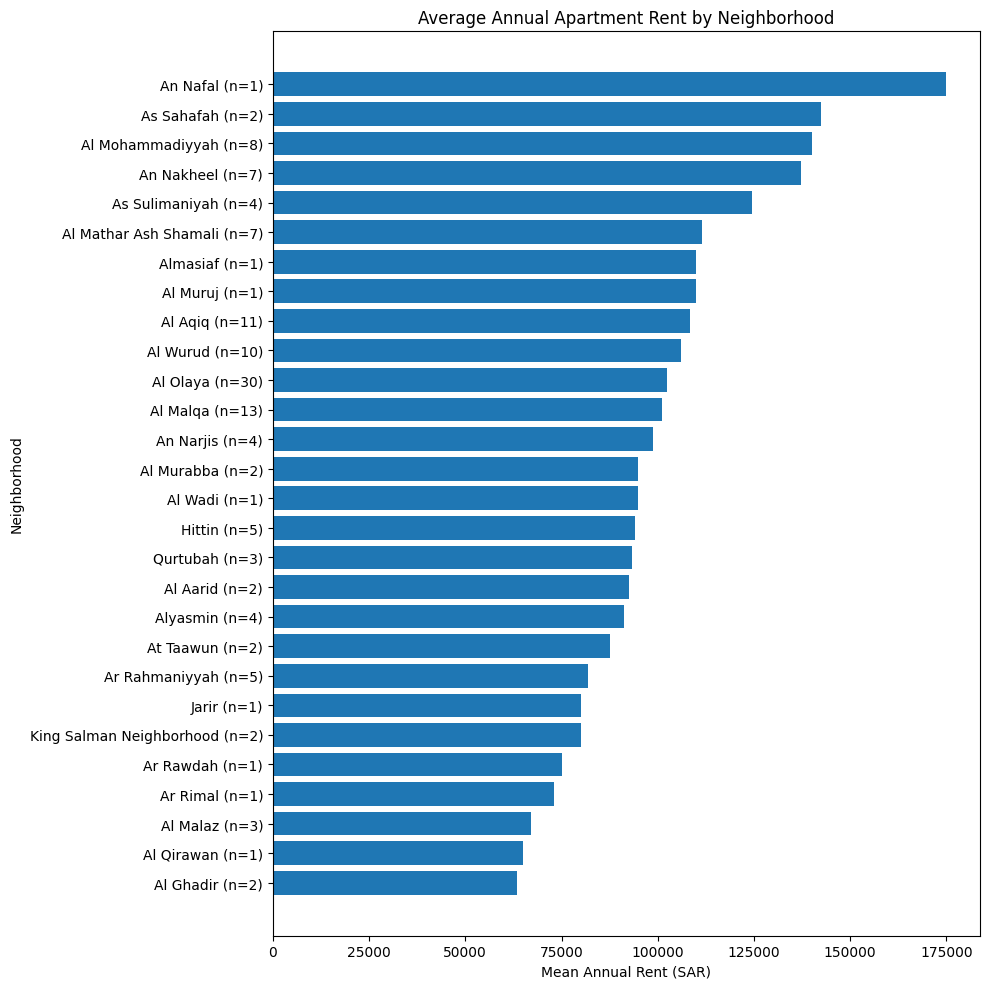

In [ ]:
# Sort neighborhoods by mean apartment rent
apartment_plot = apartment_rent_by_neighborhood.sort_values('mean')

# Add the number of apartment listings to each label
labels = [
    f"{name} (n={int(count)})"
    for name, count in zip(
        apartment_plot.index,
        apartment_plot['count']
    )
]

# Plot mean apartment rents
plt.figure(figsize=(10, 10))
plt.barh(labels, apartment_plot['mean'])

plt.title('Average Annual Apartment Rent by Neighborhood')
plt.xlabel('Mean Annual Rent (SAR)')
plt.ylabel('Neighborhood')
plt.xlim(left=0)
plt.tight_layout()
plt.show()

### Interpretation of Average Apartment Rent by Neighborhood

The chart shows differences in mean annual apartment rents across the sampled neighborhoods. An Nafal has the highest mean at 175,000 SAR, while Al Ghadir has the lowest at 63,500 SAR. However, these averages are based on only one and two listings, respectively.

Al Mohammadiyyah has a mean of 140,000 SAR based on eight apartments, compared with approximately 102,333 SAR in Al Olaya based on 30 apartments. Differences remain when comparing the same property type, although apartment size, furnishing, and other characteristics may also contribute. These results describe the collected listings and should not be generalized to all apartments in these neighborhoods.

## 23. Answering the Research Question Using Primary Data

Within the collected SATEL listings, average annual rents differ across both property types and neighborhoods. Villas have the highest mean annual rent at approximately 219,630 SAR, while studios have the lowest at 72,700 SAR.

Neighborhood comparisons depend partly on the mix of property types. For example, An Nakheel's mean rent is approximately 175,833 SAR across all property types, compared with 137,143 SAR for apartments only. Differences across neighborhoods remain in the apartment-only comparison.

Property area is positively correlated with annual rent (r = 0.637), suggesting that size is also relevant when interpreting rental differences. However, these exploratory results do not establish causal effects. Unequal group sizes, differences in property characteristics, and the limited SATEL sample restrict generalization to the wider Riyadh rental market.

Relationships and Group Comparisons

Annual rental prices varied across property types in the collected SATEL listings. Villas had the highest mean annual rent at approximately 219,630 SAR, while studios had the lowest at 72,700 SAR. Their median rents were 220,000 SAR and 67,500 SAR, respectively. Boxplots showed that duplexes had the widest interquartile range. Potential outliers appeared among villas, studios, and floors, highlighting why both means and medians were considered.

Mean annual rents also differed across neighborhoods. However, some neighborhood averages were based on very few listings. For example, Sedra had a mean of 235,000 SAR based on only two listings. Unequal sample sizes and differences in property types limit direct comparisons between neighborhoods.

To explore these differences within one property type, we compared apartments across neighborhoods. Al Mohammadiyyah had a mean annual apartment rent of 140,000 SAR based on eight listings, compared with approximately 102,333 SAR in Al Olaya based on 30 listings. In An Nakheel, the mean decreased from approximately 175,833 SAR across all property types to 137,143 SAR for apartments only, illustrating how property composition influences neighborhood averages.،،

The scatter plot showed a positive relationship between property area and annual rent, supported by a Pearson correlation of 0.637. Annual rent was also positively correlated with bathrooms (approximately 0.60) and bedrooms (approximately 0.43). These associations suggest that property characteristics should be considered when interpreting rental differences across neighborhoods and property types.


 Overall, the analysis identifies rental-price differences associated with neighborhood and property type within the collected sample. It does not establish causation or isolate the effect of each characteristic. The findings describe advertised SATEL rents and should not be generalized to the entire Riyadh rental market.

   ## Part 3: Secondary Data — Processing, Cleaning & Descriptive Statistics
   

# IT362 · Phase 2 · Part 3
## Secondary Data — Processing, Cleaning & Descriptive Statistics


**Research question (Phase 1):** In Riyadh, how do neighborhood and property type relate to average residential rental prices?

**What this notebook does**
1. Documents the secondary data source, scope and limitations.
2. Inspects the raw file, then cleans and prepares it (each step: *what / why / how*).
3. Computes descriptive statistics and distribution plots.



### 0. Secondary data

| Item | Detail |
|---|---|
| Dataset | **Aqar.fm Saudi Real Estate Listings** by *afaskar* (Hugging Face) |
| URL | https://huggingface.co/datasets/afaskar/Aqar.fm-Saudi-Real-Estate-Listings |
| File used | `aqar_fm_listings_rental_cleaned.csv` (kept exactly as downloaded) |
| Original platform | Aqar (sa.aqar.fm) — public listings scraped by the dataset author |
| License | **CC BY 4.0** (attribution required) |
| Date of the data | Collected **30 Dec 2025** according to the dataset card; listings in the file were created between Feb and Dec 2025 |
| Scope used here | Riyadh **residential** rentals: apartments, floors and villas |



In [ ]:
import sys, subprocess
try:
    import arabic_reshaper
    from bidi.algorithm import get_display
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "arabic-reshaper", "python-bidi"])

In [ ]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arabic_reshaper
from bidi.algorithm import get_display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"   # contains Arabic glyphs
os.makedirs("figures", exist_ok=True)

DATA_PATH = "aqar_fm_listings_rental_cleaned.csv"   # put the downloaded file next to this notebook

def ar(text):
    # Arabic text needs reshaping + right-to-left ordering to display correctly in matplotlib
    return get_display(arabic_reshaper.reshape(str(text)))

### 1. Load the data
The original file stays untouched in `df_raw`; all cleaning is done on a copy.

In [ ]:
df_raw = pd.read_csv(DATA_PATH)
print("Rows, columns:", df_raw.shape)
df_raw[["id", "price", "area_sqm", "num_bedrooms", "num_bathrooms", "city", "district", "category_en"]].head()

Rows, columns: (1344, 79)


,id,price,area_sqm,num_bedrooms,num_bathrooms,city,district,category_en
0,6516181,105000.0,102.0,2.0,NaN,الرياض,حي العليا,Big flat for rent
1,6479084,55000.0,50.0,1.0,1.0,الرياض,حي العليا,Apartment for rent
2,6519016,85000.0,96.0,1.0,NaN,الرياض,حي الملك فهد,Office for rent
3,6503363,1500000.0,10000.0,NaN,NaN,جده,حي الزمرد,Land for rent
4,6462507,16000.0,80.0,2.0,NaN,الرياض,حي بدر,Apartment for rent


### 2. Initial inspection of the raw data
We check size, listing types, cities, property categories, missing values and duplicates before cleaning.

In [ ]:
print("Listing type flags -> is_rental:", df_raw["is_rental"].value_counts().to_dict(),
      "| is_daily_rental:", df_raw["is_daily_rental"].value_counts().to_dict())
print("\nTop cities:"); print(df_raw["city"].value_counts().head(6).to_string())
print("\nProperty categories (all cities):"); print(df_raw["category_en"].value_counts().to_string())

key_cols = ["price", "area_sqm", "num_bedrooms", "num_bathrooms", "num_living_rooms", "furnished", "district", "create_time"]
print("\nMissing values (%) in key columns:")
print((df_raw[key_cols].isna().mean() * 100).round(1).to_string())
print("\nDuplicate listing IDs:", df_raw["id"].duplicated().sum())

Listing type flags -> is_rental: {True: 1344} | is_daily_rental: {False: 1344}

Top cities:
city
الرياض    1052
جده        122
الخبر       53
الدمام      25
بريده       13
الهفوف      11

Property categories (all cities):
category_en
Apartment for rent    1008
Villa for rent         108
Big flat for rent       83
Building for rent       25
Room for rent           25
Store for rent          24
Lounge for rent         22
Land for rent           20
Office for rent         16
Warehouse for rent      13

Missing values (%) in key columns:
price                0.0
area_sqm             0.0
num_bedrooms         8.3
num_bathrooms       29.6
num_living_rooms    31.2
furnished            0.0
district             0.0
create_time          0.0

Duplicate listing IDs: 0


**Findings from the inspection**

- The file has 1,344 rows × 79 columns. **Every row is a rental** and none is a daily rental.
- **1,052 listings are in Riyadh.** The file also contains non-residential categories (rooms, stores, lounges, offices, warehouses, land, buildings) that are not part of our research question.
- The residential categories are `Apartment for rent`, `Big flat for rent` (a floor of a house) and `Villa for rent`.
- No duplicate listing IDs. Bathrooms and living rooms have many missing values (the ad did not state them).
- Most of the 79 columns (URLs, images, descriptions, advertiser and license data, installment prices) are not needed for our analysis.

### 3. Cleaning and preprocessing
Each step states **what** was done, **why**, and **how**.

#### 3.1 Keep Riyadh residential rentals
**What:** keep only listings in Riyadh whose category is apartment, floor (*Big flat*) or villa, and create `property_type` with the same labels as the primary data (`Apartments`, `Floor`, `Villas`).
**Why:** the research question is about *residential rentals in Riyadh*; using the same property-type labels as the primary SATEL data.
**How:** boolean filters and a mapping dictionary.

In [ ]:
n_all = len(df_raw)
df_sec = df_raw[df_raw["city"] == "الرياض"].copy()
n_riyadh = len(df_sec)

category_map = {"Apartment for rent": "Apartments",
                "Big flat for rent": "Floor",
                "Villa for rent": "Villas"}
df_sec = df_sec[df_sec["category_en"].isin(category_map)].copy()
df_sec["property_type"] = df_sec["category_en"].map(category_map)
n_resid = len(df_sec)

print("All rentals:", n_all, "| Riyadh:", n_riyadh, "| Riyadh residential:", n_resid)
print(df_sec["property_type"].value_counts().to_dict())

All rentals: 1344 | Riyadh: 1052 | Riyadh residential: 951
{'Apartments': 796, 'Floor': 78, 'Villas': 77}


#### 3.2 Exclude ads posted by the SATEL company
**What:** remove listings whose advertiser name or description mentions *ساتل / Satel*.
**Why:** our primary data comes from the SATEL platform. Ads of the SATEL company on Aqar may describe the same properties, so keeping them would make the two sources overlap. Only 4 listings are affected.
**How:** `str.contains` on `company_name` and `description`.

In [ ]:
satel_mask = (df_sec["company_name"].astype(str).str.contains("ساتل")
              | df_sec["description"].astype(str).str.contains("ساتل|satel", case=False))
print("Listings related to SATEL:", int(satel_mask.sum()))
df_sec = df_sec[~satel_mask].copy()
n_no_satel = len(df_sec)
print("Rows left:", n_no_satel)

Listings related to SATEL: 4
Rows left: 947


#### 3.3 Exclude prices that are not annual rents
**What:** remove listings with `price < 10,000 SAR`.
**Why:** the research variable is the **annual** rent. The price histogram shows a natural gap between about 8,000 and 12,000 SAR, and below it there are ads whose text quotes a *monthly* amount (for example "1800 شهري") or rent a single room — these numbers are not comparable with annual rents. The gap makes 10,000 SAR a reasonable cut-off, and it removes about 10% of the residential listings, which we report as a limitation.
**How:** `price` bins to show the gap, a few example ads, then a filter.

In [ ]:
bins = [0, 3000, 5000, 8000, 10000, 12000, 20000, 30000, 50000, 100000, 500000]
print(pd.cut(df_sec["price"], bins).value_counts().sort_index().to_string())

print("\nExamples of ads priced below 10,000 SAR (price, area, bedrooms, start of the ad text):")
ex = df_sec[df_sec["price"] < 10000].sort_values("price").iloc[[0, 5, 20, 50, 80]]
for _, r in ex.iterrows():
    print(f"{r['price']:>8,.0f} | {r['area_sqm']:>6,.0f} m2 | {r['num_bedrooms']} bed | {str(r['description'])[:70]!r}")

low_mask = df_sec["price"] < 10000
print("\nListings below 10,000 SAR:", int(low_mask.sum()), f"({low_mask.mean()*100:.1f}% of residential listings)")
df_sec = df_sec[~low_mask].copy()
n_annual = len(df_sec)
print("Rows left:", n_annual)

price
(0, 3000]            31
(3000, 5000]         54
(5000, 8000]         14
(8000, 10000]         2
(10000, 12000]        1
(12000, 20000]       22
(20000, 30000]      169
(30000, 50000]      255
(50000, 100000]     323
(100000, 500000]     76

Examples of ads priced below 10,000 SAR (price, area, bedrooms, start of the ad text):
      37 |    676 m2 | 3.0 bed | 'للايجار شقه عوايل مجدده بالكامل حي الخليج بجانب محطه مترو اشبيليا طريق'
   2,000 |     65 m2 | 1.0 bed | 'للايجار الشهري استوديو عوايل حي النهضه – عرض رقم D1496 المواصفات: - ال'
   2,800 |     40 m2 | 1.0 bed | 'السلام عليكم ورحمه الله وبركاته يوجد لدينا استديوهات موثثه اثاث جديد ف'
   3,700 |     40 m2 | 1.0 bed | '\u200fB5 - منازل سكنيه موثثه  حي النرجس  شارع ظلم - مقابل جامعه الامام محمد'
   5,000 |     80 m2 | 1.0 bed | 'شقه موثثه للايجار – حي المصيف مواصفات الوحده: • صاله • مطبخ راكب • غرف'

Listings below 10,000 SAR: 100 (10.6% of residential listings)
Rows left: 847


#### 3.4 Neighborhood names
**What:** create `neighborhood_ar` and `neighborhood_key` (a normalised spelling used only for matching).
**Why:** every district in the source starts with *حي*, and the author wrote the names in normalised Arabic (for example *الصحافه* instead of *الصحافة*). The primary data spells the same neighborhoods differently (with and without *حي*, with *ة*). Comparing neighborhoods needs one common key, so the same `make_neighborhood_key` function must be applied to the primary data too.
**How:** regular expressions and character replacement (ة→ه, ى→ي, أ/إ/آ→ا).

In [ ]:
def make_neighborhood_key(name):
    # normalise an Arabic neighborhood name so the two datasets can be matched
    s = re.sub(r"^\s*حي\s+", "", str(name))              # remove the leading word 'حي'
    s = re.sub(r"[\u064B-\u0652\u0640]", "", s)           # remove diacritics and tatweel
    for a, b in [("أ", "ا"), ("إ", "ا"), ("آ", "ا"), ("ى", "ي"), ("ة", "ه")]:
        s = s.replace(a, b)
    return re.sub(r"\s+", " ", s).strip()

df_sec["neighborhood_ar"] = df_sec["district"].astype(str).str.replace(r"^\s*حي\s+", "", regex=True).str.strip()
df_sec["neighborhood_key"] = df_sec["district"].map(make_neighborhood_key)

print("Distinct neighborhoods:", df_sec["neighborhood_ar"].nunique())
print(df_sec["neighborhood_ar"].value_counts().head(8).to_string())

Distinct neighborhoods: 95
neighborhood_ar
النرجس      98
الملقا      55
العارض      48
الياسمين    42
اليرموك     41
المونسيه    34
الرمال      33
العقيق      28


#### 3.5 Data types and units


In [ ]:
rename_map = {"id": "property_id", "price": "annual_rent_sar", "num_bedrooms": "bedrooms",
              "num_bathrooms": "bathrooms", "num_living_rooms": "living_rooms"}
df_sec = df_sec.rename(columns=rename_map)

df_sec["created_at"] = pd.to_datetime(df_sec["create_time"], unit="s", utc=True)

for c in ["furnished", "ac", "lift", "maid_room", "driver_room", "pool"]:
    df_sec[c] = df_sec[c].astype(int)

for c in ["bedrooms", "bathrooms", "living_rooms"]:
    df_sec[c] = df_sec[c].astype("Int64")           # integer type that allows missing values
df_sec["annual_rent_sar"] = df_sec["annual_rent_sar"].astype(float)

print("Listing dates:", df_sec["created_at"].min().date(), "to", df_sec["created_at"].max().date())
print(df_sec["created_at"].dt.to_period("Q").value_counts().sort_index().to_dict())

Listing dates: 2025-02-10 to 2025-12-29
{Period('2025Q1', 'Q-DEC'): 1, Period('2025Q2', 'Q-DEC'): 2, Period('2025Q3', 'Q-DEC'): 116, Period('2025Q4', 'Q-DEC'): 728}


/tmp/ipykernel_6993/283753269.py:15: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  print(df_sec["created_at"].dt.to_period("Q").value_counts().sort_index().to_dict())


#### 3.6 Missing values


In [ ]:
miss = df_sec[["annual_rent_sar", "area_sqm", "bedrooms", "bathrooms", "living_rooms",
           "neighborhood_ar", "property_type", "created_at"]].isna().sum()
miss_table = miss.to_frame("n_missing")
miss_table["percent"] = (miss / len(df_sec) * 100).round(1)
miss_table

,n_missing,percent
annual_rent_sar,0,0.0
area_sqm,0,0.0
bedrooms,13,1.5
bathrooms,186,22.0
living_rooms,201,23.7
neighborhood_ar,0,0.0
property_type,0,0.0
created_at,0,0.0


#### 3.7 Duplicates


In [ ]:
print("Duplicate property IDs:", df_sec["property_id"].duplicated().sum())
print("Duplicate rows (all columns except id/url):",
      df_sec.drop(columns=["property_id", "url"]).duplicated().sum())

Duplicate property IDs: 0
Duplicate rows (all columns except id/url): 0


#### 3.8 Flag outliers


In [ ]:
def upper_fence(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return q3 + 1.5 * (q3 - q1)

fences = df_sec.groupby("property_type")["annual_rent_sar"].apply(upper_fence)
df_sec["price_outlier_iqr"] = df_sec["annual_rent_sar"] > df_sec["property_type"].map(fences)
df_sec["area_flag"] = df_sec["area_sqm"] > 1000

print("Upper fences (SAR):", fences.round(0).to_dict())
print("Rent outliers:", int(df_sec["price_outlier_iqr"].sum()), f"({df_sec['price_outlier_iqr'].mean()*100:.1f}%)",
      df_sec.groupby("property_type")["price_outlier_iqr"].sum().to_dict())
print("Listings with area above 1,000 m2:", int(df_sec["area_flag"].sum()))

Upper fences (SAR): {'Apartments': 117500.0, 'Floor': 122500.0, 'Villas': 237500.0}
Rent outliers: 32 (3.8%) {'Apartments': 22, 'Floor': 2, 'Villas': 8}
Listings with area above 1,000 m2: 21


#### 3.9 Transformation: log of rent


In [ ]:
df_sec["log_annual_rent"] = np.log(df_sec["annual_rent_sar"])
print("Skewness of rent (SAR):", round(df_sec["annual_rent_sar"].skew(), 2))
print("Skewness of ln(rent):  ", round(df_sec["log_annual_rent"].skew(), 2))

Skewness of rent (SAR): 3.2
Skewness of ln(rent):   0.44


#### 3.10 Keep the columns we need and finalise
**What:** keep 19 columns (the ones that match the primary data, plus the amenity columns) and drop the rest (titles, URLs, images, descriptions, advertiser and license data, installment prices, coordinates and other unused fields).
**Why:** the assignment asks to remove irrelevant features, and the advertiser columns contain company names and license numbers that we do not need to hand over.
**How:** column selection.

In [ ]:
final_cols = ["property_id", "neighborhood_ar", "neighborhood_key", "property_type", "annual_rent_sar",
              "area_sqm", "bedrooms", "bathrooms", "living_rooms", "furnished", "ac", "lift",
              "maid_room", "driver_room", "pool", "created_at", "log_annual_rent",
              "price_outlier_iqr", "area_flag"]
df_clean = df_sec[final_cols].reset_index(drop=True)

steps = pd.DataFrame({
    "step": ["All rental listings in the file", "Riyadh only", "Residential types only (apartment, floor, villa)",
             "Without SATEL-company ads", "Annual rents only (price >= 10,000 SAR)"],
    "rows": [n_all, n_riyadh, n_resid, n_no_satel, n_annual]})
steps["removed"] = (-steps["rows"].diff()).fillna(0).astype(int)
display(steps)
print("Final dataset:", df_clean.shape)
df_clean.head()

,step,rows,removed
0,All rental listings in the file,1344,0
1,Riyadh only,1052,292
2,"Residential types only (apartment, floor, villa)",951,101
3,Without SATEL-company ads,947,4
4,"Annual rents only (price >= 10,000 SAR)",847,100


Final dataset: (847, 19)


,property_id,neighborhood_ar,neighborhood_key,property_type,annual_rent_sar,area_sqm,bedrooms,bathrooms,living_rooms,furnished,ac,lift,maid_room,driver_room,pool,created_at,log_annual_rent,price_outlier_iqr,area_flag
0,6516181,العليا,العليا,Floor,105000.0,102.0,2,<NA>,<NA>,0,0,0,0,0,0,2025-12-22 07:25:33+00:00,11.561716,False,False
1,6479084,العليا,العليا,Apartments,55000.0,50.0,1,1,<NA>,1,1,0,0,0,0,2025-11-24 12:28:39+00:00,10.915088,False,False
2,6462507,بدر,بدر,Apartments,16000.0,80.0,2,<NA>,<NA>,0,0,0,0,0,0,2025-11-10 22:26:32+00:00,9.680344,False,False
3,6496667,النرجس,النرجس,Villas,135000.0,373.0,3,5,3,0,1,0,0,0,0,2025-12-07 15:38:29+00:00,11.813030,False,False
4,6522462,الحمراء,الحمراء,Apartments,45000.0,600.0,3,2,1,0,1,0,0,0,0,2025-12-26 19:56:29+00:00,10.714418,False,False


### 4. Descriptive statistics

In [ ]:
num_cols = ["annual_rent_sar", "area_sqm", "bedrooms", "bathrooms", "living_rooms"]
num = df_clean[num_cols].astype(float)
stats = num.agg(["count", "mean", "median", "min", "max", "std"]).T
stats["q1"] = num.quantile(0.25)
stats["q3"] = num.quantile(0.75)
stats["skew"] = num.skew()
stats = stats.round(2)
stats.to_csv("descriptive_stats_secondary.csv")
stats

,count,mean,median,min,max,std,q1,q3,skew
annual_rent_sar,847.0,60130.79,50000.0,10000.0,400000.0,42962.62,33000.0,75000.0,3.20
area_sqm,847.0,300.99,138.0,1.0,50000.0,1736.16,100.0,300.0,27.81
bedrooms,834.0,2.54,3.0,1.0,7.0,1.42,1.0,3.0,0.65
bathrooms,661.0,2.17,2.0,1.0,7.0,1.25,1.0,3.0,0.87
living_rooms,646.0,1.00,1.0,0.0,5.0,0.71,1.0,1.0,1.69


In [ ]:
by_type = df_clean.groupby("property_type").agg(
    listings=("property_id", "count"),
    median_rent_sar=("annual_rent_sar", "median"),
    median_area_sqm=("area_sqm", "median"),
    furnished_percent=("furnished", lambda s: round(s.mean() * 100, 1)))
by_type["share_of_listings_percent"] = (by_type["listings"] / len(df_clean) * 100).round(1)
by_type.to_csv("descriptive_by_property_type_secondary.csv")
display(by_type)

feat = (df_clean[["furnished", "ac", "lift", "maid_room", "driver_room", "pool"]].mean() * 100).round(1)
print("Share of listings with each feature (%):"); print(feat.to_string())
hood_counts = df_clean["neighborhood_key"].value_counts()
print("\nDistinct neighborhoods:", len(hood_counts), "| with fewer than 5 listings:", int((hood_counts < 5).sum()))
print(f"Share of listings in the top 5 neighborhoods: {hood_counts.head(5).sum() / len(df_clean) * 100:.1f}%")

,listings,median_rent_sar,median_area_sqm,furnished_percent,share_of_listings_percent
property_type,,,,,
Apartments,699,42000.0,121.0,10.4,82.5
Floor,74,75000.0,306.0,4.1,8.7
Villas,74,110000.0,334.0,9.5,8.7


Share of listings with each feature (%):
furnished       9.8
ac             56.8
lift           31.1
maid_room       3.2
driver_room     1.2
pool            0.7

Distinct neighborhoods: 95 | with fewer than 5 listings: 55
Share of listings in the top 5 neighborhoods: 33.5%


The by-type table only *describes* each group; comparing groups and explaining the differences is done in Part 4.

### 5. Distribution plots

#### Figure 1 — Distribution of annual rent (SAR)

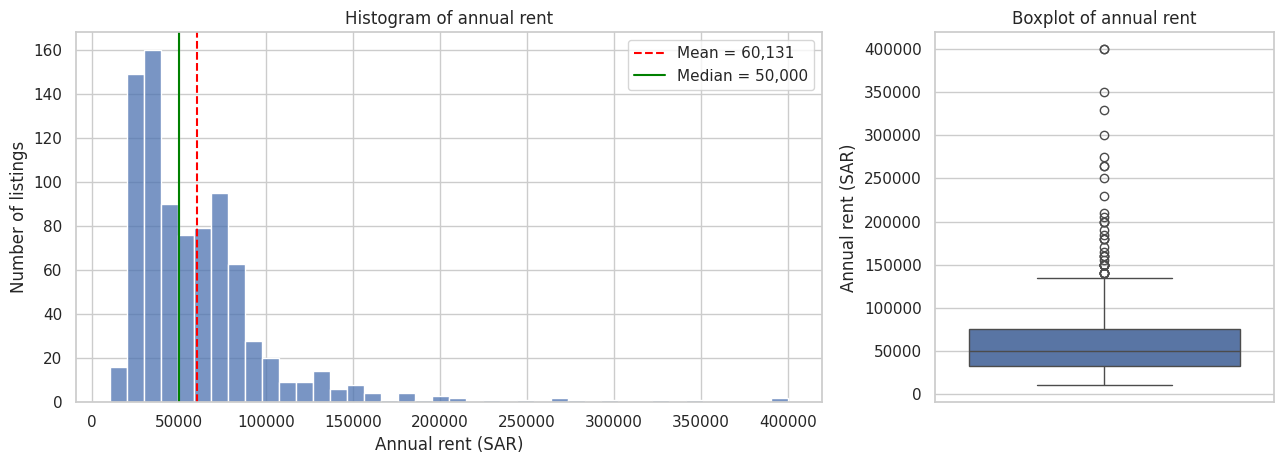

mean=60,131 median=50,000 std=42,963 min=10,000 max=400,000 skew=3.20
{0.25: 33000, 0.75: 75000, 0.9: 100000, 0.99: 240800}


In [ ]:
rent = df_clean["annual_rent_sar"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [2.2, 1]})
sns.histplot(rent, bins=40, color="#4C72B0", ax=axes[0])
axes[0].axvline(rent.mean(), color="red", ls="--", label=f"Mean = {rent.mean():,.0f}")
axes[0].axvline(rent.median(), color="green", ls="-", label=f"Median = {rent.median():,.0f}")
axes[0].set_title("Histogram of annual rent")
axes[0].set_xlabel("Annual rent (SAR)"); axes[0].set_ylabel("Number of listings")
axes[0].legend()
sns.boxplot(y=rent, color="#4C72B0", ax=axes[1])
axes[1].set_title("Boxplot of annual rent"); axes[1].set_ylabel("Annual rent (SAR)")
plt.tight_layout()
plt.savefig("figures/fig1_rent_distribution.png", dpi=150)
plt.show()
q = rent.quantile([0.25, 0.75, 0.9, 0.99]).to_dict()
print(f"mean={rent.mean():,.0f} median={rent.median():,.0f} std={rent.std():,.0f} min={rent.min():,.0f} max={rent.max():,.0f} skew={rent.skew():.2f}")
print({k: round(v) for k, v in q.items()})

**Insight (Figure 1).** Annual rent is strongly right-skewed: the **median is 50,000 SAR** and the **mean is 60,131 SAR** (about 20% higher); the standard deviation is 42,963 SAR and the skewness is 3.20. Half of the listings are between 33,000 and 75,000 SAR; the 90th percentile is 100,000 SAR, the 99th is about 240,800 SAR and the maximum is 400,000 SAR. The minimum is 10,000 SAR because of the cut-off in step 3.3. Because of the skew, the **median describes a typical rent better than the mean**. This histogram mixes apartments, floors and villas, so part of the long right tail comes from villas; Within their own property type, 32 listings (3.8%) are flagged as high-rent outliers (22 apartments, 2 floors, 8 villas).

#### Figure 2 — Distribution of ln(annual rent)

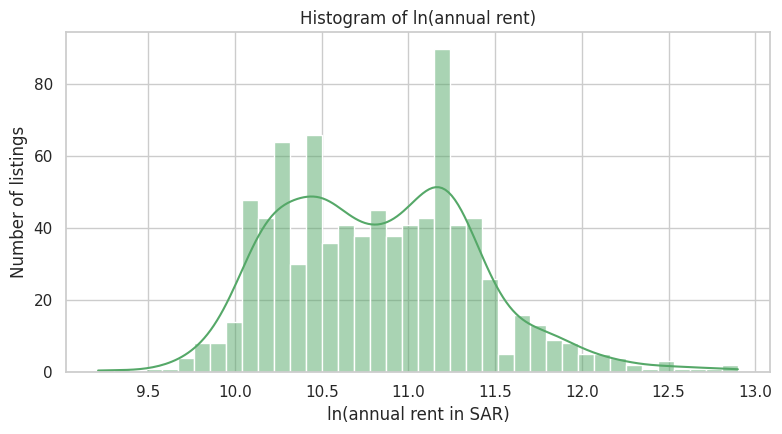

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df_clean["log_annual_rent"], bins=40, kde=True, color="#55A868", ax=ax)
ax.set_title("Histogram of ln(annual rent)")
ax.set_xlabel("ln(annual rent in SAR)"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig2_log_rent_distribution.png", dpi=150)
plt.show()

**Insight (Figure 2).** After the log transformation the skewness drops from 3.20 to about 0.44, so the shape is much closer to symmetric all reported averages stay in SAR.

#### Figure 3 — Number of listings by property type

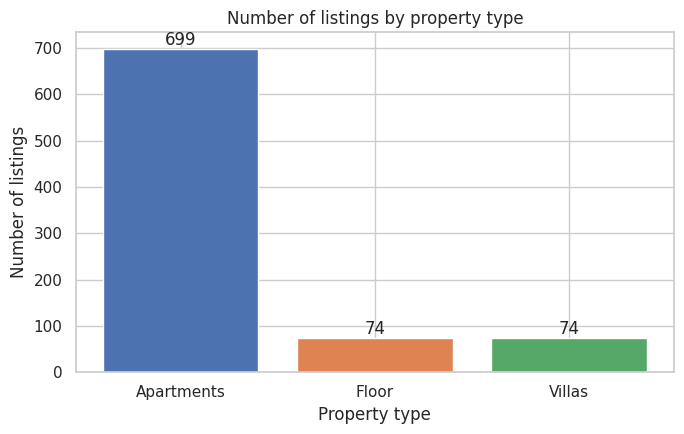

{'Apartments': 82.5, 'Floor': 8.7, 'Villas': 8.7}


In [ ]:
type_counts = df_clean["property_type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(type_counts.index, type_counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.bar_label(bars)
ax.set_title("Number of listings by property type")
ax.set_xlabel("Property type"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig3_listings_by_property_type.png", dpi=150)
plt.show()
print((df_clean["property_type"].value_counts(normalize=True) * 100).round(1).to_dict())

**Insight (Figure 3).** The sample has **699 apartments (82.5%)**, 74 floors (8.7%) and 74 villas (8.7%). Apartments dominate, but floors and villas each have 74 listings, so all three types have enough listings to be described. The primary data also has compounds, duplexes and studios, which have no counterpart in this dataset.

#### Figure 4 — Distribution of property area (up to 1,000 m²)

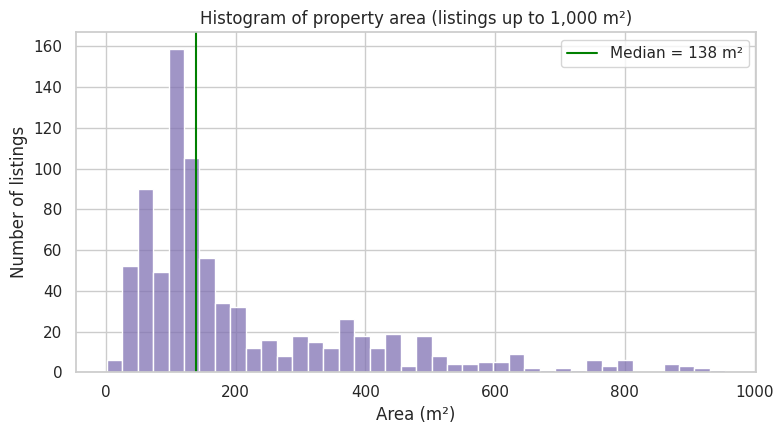

Listings not shown (area above 1,000 m2): 21
Median area by type: {'Apartments': 121.0, 'Floor': 306.0, 'Villas': 334.0}


In [ ]:
area_plot = df_clean.loc[df_clean["area_sqm"] <= 1000, "area_sqm"]
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(area_plot, bins=40, color="#8172B3", ax=ax)
ax.axvline(df_clean["area_sqm"].median(), color="green", label=f"Median = {df_clean['area_sqm'].median():,.0f} m²")
ax.set_title("Histogram of property area (listings up to 1,000 m²)")
ax.set_xlabel("Area (m²)"); ax.set_ylabel("Number of listings")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig4_area_distribution.png", dpi=150)
plt.show()
print("Listings not shown (area above 1,000 m2):", int(df_clean["area_flag"].sum()))
print("Median area by type:", df_clean.groupby("property_type")["area_sqm"].median().round(0).to_dict())

**Insight (Figure 4).** The **median area is 138 m²** and half of the listings are between 100 and 300 m². The distribution is right-skewed. The chart shows listings up to 1,000 m² to keep it readable; **21 listings above 1,000 m²** (the largest is 50,000 m², a villa) are not shown and are flagged in `area_flag`, because such values are probably land or plot size entered by the advertiser. The three property types differ clearly in size (median 121 m² for apartments, 306 m² for floors and 334 m² for villas)

#### Figure 5 — Number of listings by bedrooms

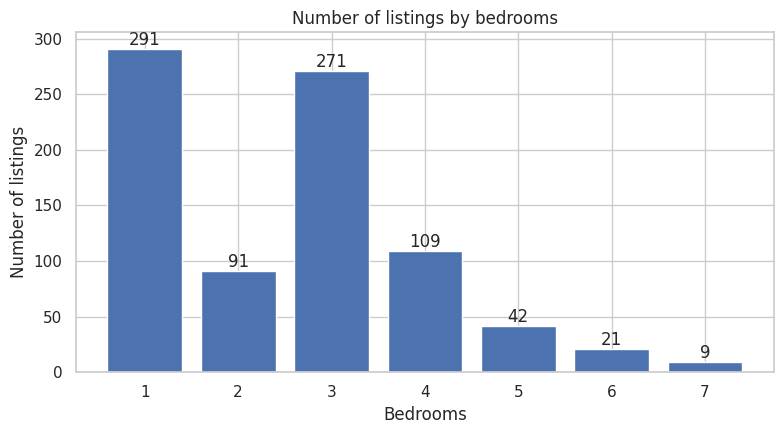

Missing: 13
{np.int64(1): 34.4, np.int64(2): 10.7, np.int64(3): 32.0, np.int64(4): 12.9, np.int64(5): 5.0, np.int64(6): 2.5, np.int64(7): 1.1}


In [ ]:
bed_counts = df_clean["bedrooms"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(bed_counts.index.astype(str), bed_counts.values, color="#4C72B0")
ax.bar_label(bars)
ax.set_title("Number of listings by bedrooms")
ax.set_xlabel("Bedrooms"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig5_listings_by_bedrooms.png", dpi=150)
plt.show()
print("Missing:", int(df_clean["bedrooms"].isna().sum()))
print((df_clean["bedrooms"].value_counts().sort_index() / len(df_clean) * 100).round(1).to_dict())

**Insight (Figure 5).** **One-bedroom (291 listings, 34.4%) and three-bedroom (271, 32.0%) listings are the most common**, followed by four (109, 12.9%) and two bedrooms (91, 10.7%). Listings with five or more bedrooms are rare (72 listings, 8.5%), and the bedroom count is missing for 13 listings (1.5%).

#### Figure 6 — Number of listings by bathrooms

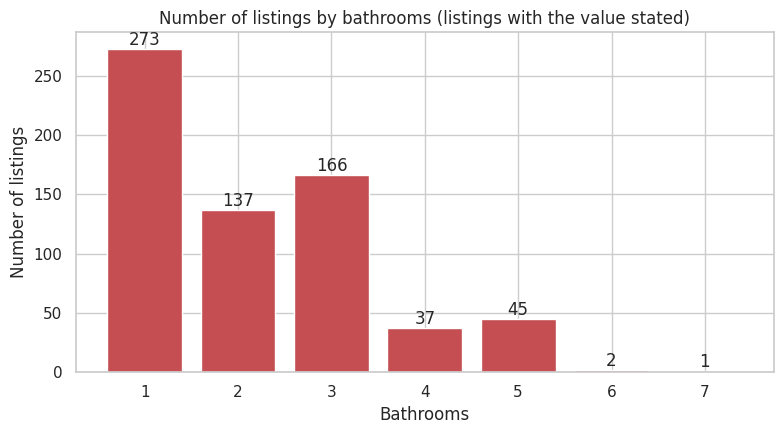

Stated: 661 | missing: 186
{np.int64(1): 41.3, np.int64(2): 20.7, np.int64(3): 25.1, np.int64(4): 5.6, np.int64(5): 6.8, np.int64(6): 0.3, np.int64(7): 0.2}


In [ ]:
bath_counts = df_clean["bathrooms"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(bath_counts.index.astype(str), bath_counts.values, color="#C44E52")
ax.bar_label(bars)
ax.set_title("Number of listings by bathrooms (listings with the value stated)")
ax.set_xlabel("Bathrooms"); ax.set_ylabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig6_listings_by_bathrooms.png", dpi=150)
plt.show()
stated = df_clean["bathrooms"].notna().sum()
print("Stated:", int(stated), "| missing:", int(df_clean["bathrooms"].isna().sum()))
print((df_clean["bathrooms"].value_counts().sort_index() / stated * 100).round(1).to_dict())

**Insight (Figure 6).** Bathrooms are stated for 661 listings; **186 listings (22.0%) do not state them**, so the chart describes only the listings with the value. Among them, **one bathroom is the most common (273 listings, 41.3%)**, followed by three (166, 25.1%) and two (137, 20.7%); four, five or more bathrooms are less common.

#### Figure 7 — Number of listings in the 15 most frequent neighborhoods

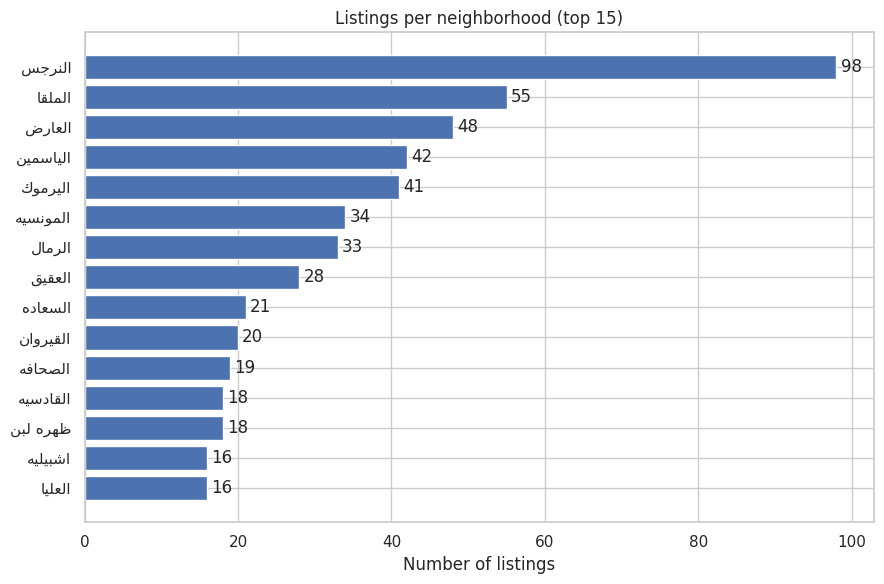

In [ ]:
top15 = df_clean["neighborhood_ar"].value_counts().head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh([ar(n) for n in top15.index], top15.values, color="#4C72B0")
ax.bar_label(bars, padding=3)
ax.set_title("Listings per neighborhood (top 15)")
ax.set_xlabel("Number of listings")
plt.tight_layout()
plt.savefig("figures/fig7_top15_neighborhoods.png", dpi=150)
plt.show()

**Insight (Figure 7).** The 847 listings are spread over 95 neighborhoods, but unevenly: **Al Narjis (98), Al Malqa (55), Al Aridh (48), Al Yasmin (42) and Al Yarmuk (41)** hold 33.5% of all listings, while **55 of the 95 neighborhoods have fewer than 5 listings**.

### 6. Export for Part 4
We export (1) the cleaned dataset, (2) a data dictionary that explains every column and shows which column matches the primary SATEL data, and (3) the descriptive tables saved above.

In [ ]:
df_clean.to_csv("secondary_cleaned.csv", index=False, encoding="utf-8-sig")

dictionary = pd.DataFrame([
    ["property_id", "int", "listing ID on Aqar", "Unique ID of the listing (source column `id`).", "property_id"],
    ["neighborhood_ar", "text (Arabic)", "95 neighborhoods", "Neighborhood name without the leading word 'حي'; spelling as in the source (normalised Arabic, e.g. الصحافه).", "neighborhood_ar (spelling differs)"],
    ["neighborhood_key", "text (Arabic)", "normalised key", "Normalised spelling for matching (no 'حي', ة→ه, ى→ي, أ/إ/آ→ا). Apply the same make_neighborhood_key function to the primary data before matching.", "— (create from primary neighborhood_ar)"],
    ["property_type", "text", "Apartments / Floor / Villas", "Property type. Apartment for rent → Apartments; Big flat for rent → Floor; Villa for rent → Villas.", "property_type (3 of 6 types)"],
    ["annual_rent_sar", "float", "SAR per year, >= 10,000", "Advertised annual rent (asking price).", "annual_rent_sar"],
    ["area_sqm", "float", "m²", "Property area as stated in the ad (see area_flag).", "area_sqm"],
    ["bedrooms", "Int64", "count; 13 missing", "Number of bedrooms.", "bedrooms"],
    ["bathrooms", "Int64", "count; 186 missing (22%)", "Number of bathrooms (missing = not stated in the ad).", "bathrooms"],
    ["living_rooms", "Int64", "count; 201 missing (24%)", "Number of living rooms (missing = not stated).", "— (not in primary)"],
    ["furnished", "int", "1 = furnished, 0 = not", "Furnishing status (binary).", "furnishing (3 categories; needs recoding)"],
    ["ac", "int", "1/0", "Has air conditioning.", "— (not in primary)"],
    ["lift", "int", "1/0", "Building has an elevator.", "— (not in primary)"],
    ["maid_room", "int", "1/0", "Has a maid's room.", "— (not in primary)"],
    ["driver_room", "int", "1/0", "Has a driver's room.", "— (not in primary)"],
    ["pool", "int", "1/0", "Has a swimming pool.", "— (not in primary)"],
    ["created_at", "datetime (UTC)", "Feb–Dec 2025", "Date and time the listing was created (converted from a Unix timestamp).", "created_at"],
    ["log_annual_rent", "float", "ln(SAR)", "Natural log of annual rent; derived column for skew handling and plots.", "— (derived)"],
    ["price_outlier_iqr", "bool", "True/False", "Rent above the IQR upper fence of its own property type (flagged, not removed).", "— (derived)"],
    ["area_flag", "bool", "True/False", "Area above 1,000 m² (probably land/plot size; flagged, not removed).", "— (derived)"],
], columns=["column", "type", "unit / values", "description", "matches primary (SATEL) column"])

dictionary.to_csv("data_dictionary_secondary.csv", index=False, encoding="utf-8-sig")
dictionary

,column,type,unit / values,description,matches primary (SATEL) column
0,property_id,int,listing ID on Aqar,Unique ID of the listing (source column `id`).,property_id
1,neighborhood_ar,text (Arabic),95 neighborhoods,Neighborhood name without the leading word 'حي...,neighborhood_ar (spelling differs)
2,neighborhood_key,text (Arabic),normalised key,"Normalised spelling for matching (no 'حي', ة→ه...",— (create from primary neighborhood_ar)
3,property_type,text,Apartments / Floor / Villas,Property type. Apartment for rent → Apartments...,property_type (3 of 6 types)
4,annual_rent_sar,float,"SAR per year, >= 10,000",Advertised annual rent (asking price).,annual_rent_sar
5,area_sqm,float,m²,Property area as stated in the ad (see area_fl...,area_sqm
6,bedrooms,Int64,count; 13 missing,Number of bedrooms.,bedrooms
7,bathrooms,Int64,count; 186 missing (22%),Number of bathrooms (missing = not stated in t...,bathrooms
8,living_rooms,Int64,count; 201 missing (24%),Number of living rooms (missing = not stated).,— (not in primary)
9,furnished,int,"1 = furnished, 0 = not",Furnishing status (binary).,furnishing (3 categories; needs recoding)


## 4. Secondary Data EDA: Relationships, Correlations & Group Comparisons

This section explores the relationships between variables in the cleaned secondary dataset. The analysis focuses on annual rent, property area, property type, and neighborhood to identify patterns that are relevant to the research question.

In [3]:
import pandas as pd

secondary_df = pd.read_csv('secondary_cleaned.csv')
secondary_df[['annual_rent_sar', 'area_sqm', 'property_type', 'neighborhood_ar']].head()

,annual_rent_sar,area_sqm,property_type,neighborhood_ar
0,105000.0,102.0,Floor,العليا
1,55000.0,50.0,Apartments,العليا
2,16000.0,80.0,Apartments,بدر
3,135000.0,373.0,Villas,النرجس
4,45000.0,600.0,Apartments,الحمراء


### 4.1 Relationship Between Property Area and Annual Rent

The relationship between property area and annual rent was examined to determine whether larger properties tend to have higher rental prices.

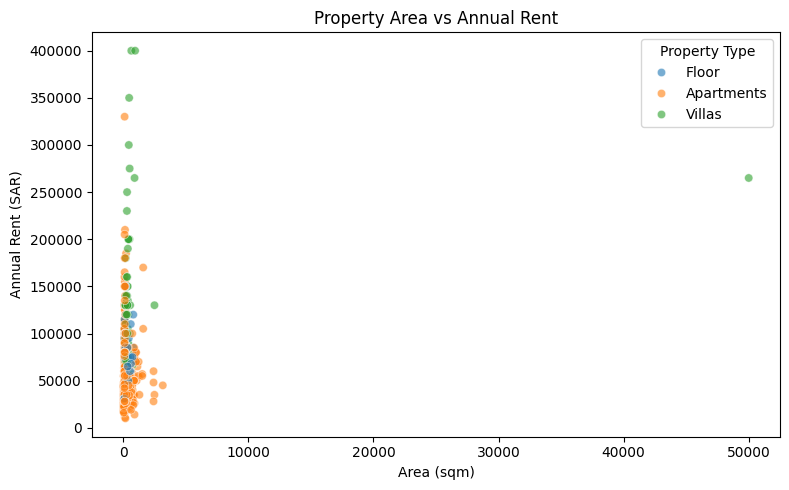

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=secondary_df,
    x='area_sqm',
    y='annual_rent_sar',
    hue='property_type',
    alpha=0.6
)

plt.title('Property Area vs Annual Rent')
plt.xlabel('Area (sqm)')
plt.ylabel('Annual Rent (SAR)')
plt.legend(title='Property Type')
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot using all observations shows that most properties are concentrated within a relatively small range of property areas. However, a flagged observation with an area of approximately 50,000 sqm stretches the x-axis and compresses the remaining observations, making the main relationship between property area and annual rent difficult to observe. Therefore, a second plot is used to examine the relationship more clearly after excluding the flagged area values from the visualization only.

### Relationship After Excluding Flagged Area Values

To visualize the main pattern more clearly, observations identified by the `area_flag` variable are excluded from the following plot only. The original secondary dataset remains unchanged.

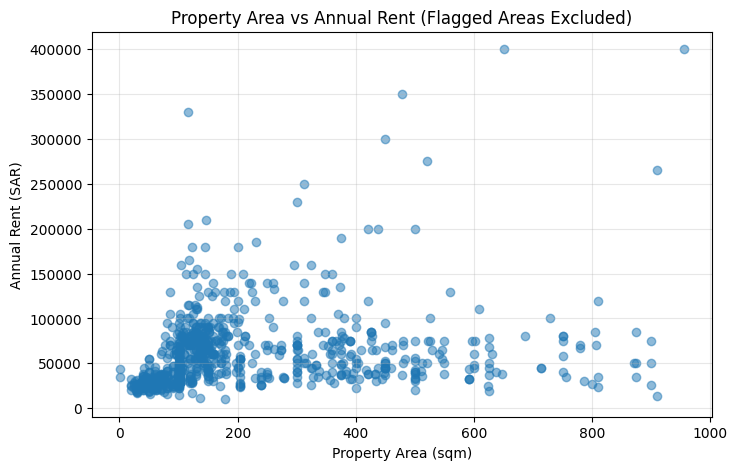

In [8]:
# Exclude flagged area values for visualization only
plot_df = secondary_df[secondary_df['area_flag'] == False]

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_df['area_sqm'],
    plot_df['annual_rent_sar'],
    alpha=0.5
)

plt.xlabel('Property Area (sqm)')
plt.ylabel('Annual Rent (SAR)')
plt.title('Property Area vs Annual Rent (Flagged Areas Excluded)')
plt.grid(alpha=0.3)

plt.show()

### Interpretation

After excluding the flagged area values from the visualization, the relationship between property area and annual rent becomes clearer. Most properties are concentrated below approximately 600 sqm, with rental prices varying considerably within similar property sizes. Although some larger properties have higher rents, the wide spread of rental prices suggests that property area alone does not fully explain the variation in annual rent. Other factors, such as property type and neighborhood, may also be associated with rental prices.

### Correlation Analysis

We calculate correlations among the relevant numerical variables after excluding the flagged area values to examine the direction and strength of their relationships.

In [9]:
# Select relevant numerical variables
numeric_cols = [
    'annual_rent_sar',
    'area_sqm',
    'bedrooms',
    'bathrooms'
]

# Calculate the correlation matrix
correlation_matrix = plot_df[numeric_cols].corr()

correlation_matrix

,annual_rent_sar,area_sqm,bedrooms,bathrooms
annual_rent_sar,1.000000,0.244008,0.539228,0.682732
area_sqm,0.244008,1.000000,0.449220,0.297440
bedrooms,0.539228,0.449220,1.000000,0.787763
bathrooms,0.682732,0.297440,0.787763,1.000000


### Correlation Heatmap

The correlation matrix is visualized using a heatmap to make the relationships among the numerical variables easier to compare.

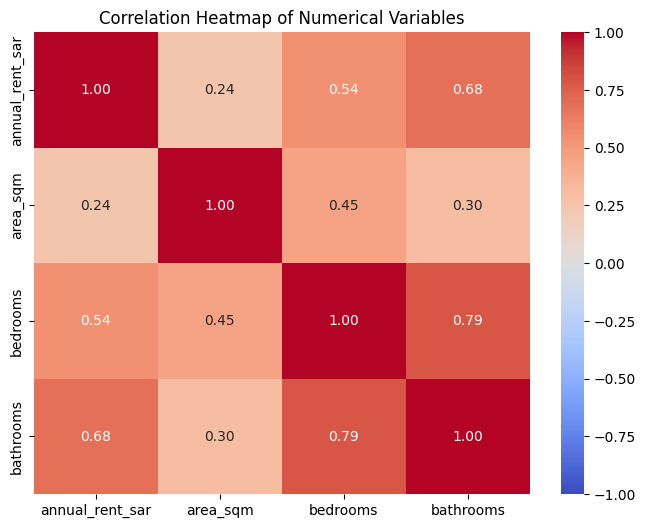

In [10]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

### Interpretation

The correlation results show that annual rent has a weak positive correlation with property area (0.24). Annual rent has a moderate positive correlation with the number of bedrooms (0.54) and a stronger positive correlation with the number of bathrooms (0.68). The strongest correlation is between bedrooms and bathrooms (0.79). These results suggest that annual rent may be related to several property characteristics rather than property area alone.

## Annual Rent by Property Type

To examine how rental prices vary across property types, we compare the mean and median annual rent for each property type.

In [11]:
# Calculate mean and median annual rent by property type
property_type_rent = secondary_df.groupby('property_type')['annual_rent_sar'].agg(
    Mean='mean',
    Median='median'
).round(0)

property_type_rent

,Mean,Median
property_type,,
Apartments,51224.0,42000.0
Floor,74054.0,75000.0
Villas,130338.0,110000.0


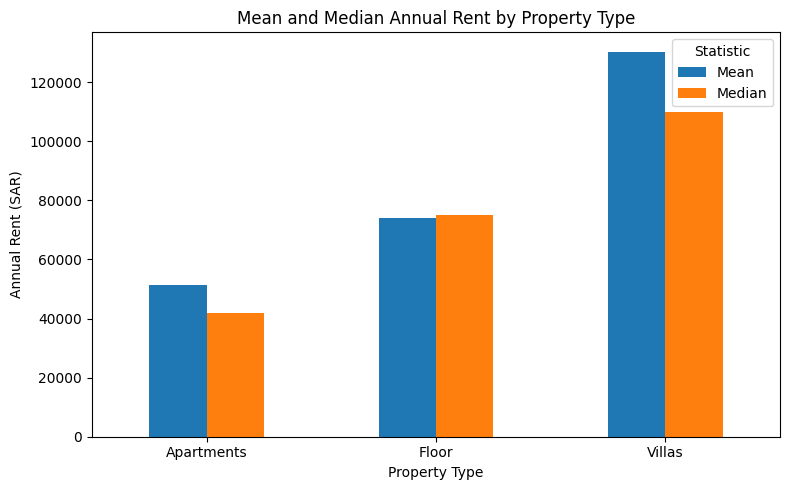

In [12]:
# Plot mean and median annual rent by property type
property_type_rent.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Mean and Median Annual Rent by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Annual Rent (SAR)')
plt.xticks(rotation=0)
plt.legend(title='Statistic')
plt.tight_layout()
plt.show()

### Interpretation

Villas have the highest annual rental prices, followed by floors and apartments. The mean rent for villas is about 130,338 SAR, compared with a median of 110,000 SAR. Apartments have the lowest rental prices, with a mean of about 51,224 SAR and a median of 42,000 SAR. For floors, the mean and median are very close. These results show that annual rental prices vary across property types.

### Annual Rent by Neighborhood

To compare rental prices across neighborhoods, we first examine the number of listings available in each neighborhood. Neighborhoods with very few listings may not provide a reliable representation of typical rental prices.

In [13]:
# Count the number of listings in each neighborhood
neighborhood_counts = secondary_df['neighborhood_ar'].value_counts()

neighborhood_counts.head(15)

,count
neighborhood_ar,
النرجس,98
الملقا,55
العارض,48
الياسمين,42
اليرموك,41
المونسيه,34
الرمال,33
العقيق,28
السعاده,21


#### Comparison of the Most Represented Neighborhoods

For a clearer and more reliable comparison, we focus on the 10 neighborhoods with the largest number of listings in the secondary dataset. We compare both the mean and median annual rent for these neighborhoods.

In [14]:
# Select the 10 neighborhoods with the most listings
top_neighborhoods = neighborhood_counts.head(10).index

# Calculate mean and median annual rent
neighborhood_rent = (
    secondary_df[secondary_df['neighborhood_ar'].isin(top_neighborhoods)]
    .groupby('neighborhood_ar')['annual_rent_sar']
    .agg(Mean='mean', Median='median')
    .round(0)
)

# Sort by median annual rent
neighborhood_rent = neighborhood_rent.sort_values(
    by='Median',
    ascending=False
)

neighborhood_rent

,Mean,Median
neighborhood_ar,,
النرجس,77974.0,75000.0
العارض,71792.0,70000.0
المونسيه,59659.0,60000.0
الرمال,60642.0,60000.0
القيروان,63950.0,58000.0
الياسمين,59929.0,52500.0
الملقا,62018.0,50000.0
العقيق,54893.0,41000.0
السعاده,44571.0,40000.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 6.8 MB/s eta 0:00:00


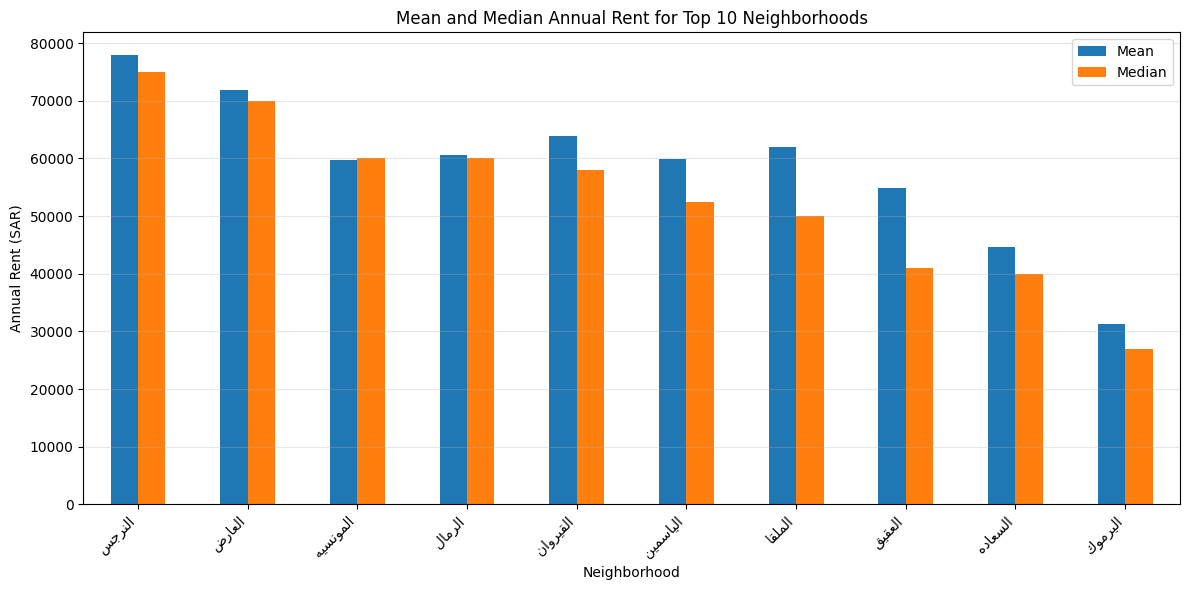

In [16]:
!pip -q install arabic-reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

# Create a copy for plotting
neighborhood_plot = neighborhood_rent.copy()

# Fix Arabic neighborhood names for display
arabic_labels = [
    get_display(arabic_reshaper.reshape(str(name)))
    for name in neighborhood_plot.index
]

# Plot mean and median annual rent
ax = neighborhood_plot[['Mean', 'Median']].plot(
    kind='bar',
    figsize=(12, 6)
)

ax.set_xticklabels(arabic_labels, rotation=45, ha='right')

plt.xlabel('Neighborhood')
plt.ylabel('Annual Rent (SAR)')
plt.title('Mean and Median Annual Rent for Top 10 Neighborhoods')
plt.legend(['Mean', 'Median'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Rental prices vary across the 10 most represented neighborhoods. Al Narjis has the highest median annual rent at about 75,000 SAR, followed by Al Arid at 70,000 SAR. In contrast, Al Yarmuk has the lowest median annual rent at about 27,000 SAR. The differences in mean and median values across neighborhoods indicate that rental prices vary by location. However, these results are based only on the most represented neighborhoods in the secondary dataset.

### Secondary Data EDA Summary

The secondary data analysis shows that annual rental prices vary across property characteristics and locations. Property area has a weak positive correlation with annual rent (0.24), suggesting that area alone does not explain most of the variation in rental prices. Bedrooms and bathrooms show stronger positive correlations with annual rent (0.54 and 0.68, respectively).

Rental prices also differ across property types. Villas have the highest mean and median annual rents, followed by floors and apartments. Differences are also observed across the most represented neighborhoods, with Al Narjis and Al Arid showing higher median rents than the other neighborhoods included in the comparison.

Overall, the secondary data suggests that both property type and neighborhood are associated with differences in annual residential rental prices. These findings are relevant to the research question and can be compared with the primary data results in the next stage.

### Metrics for Comparison with Primary Data

The following common indicators can be used in the comparison between the primary and secondary datasets:

- Mean and median annual rent.
- Mean and median annual rent by property type.
- Mean and median annual rent by neighborhood where comparable neighborhoods are available.
- Relationship between property area and annual rent.